# Khám phá dữ liệu GoEmotions cho phân loại cảm xúc đa nhãn

**Đầu ra:** số mẫu, phân bố đầy đủ 28 nhãn, 30 ví dụ có ID, kiểm tra chất lượng,
biểu đồ và báo cáo có thể chạy lại. Các kết quả được tính từ dữ liệu thật ở revision cố định.

**Cách học:** đọc phần giải thích → chạy ô code ngay bên dưới bằng `Shift+Enter` →
đối chiếu bảng/biểu đồ → đọc nhận xét. Có thể dùng **Restart Kernel and Run All Cells**.
Notebook đã lưu output để đọc ngay cả khi chưa cài Python.

**Phạm vi:** phần EDA trong mục 4, 5 và sản phẩm tuần 1 của file
`KE_HOACH_A_Z_DE_TAI_01_GOEMOTIONS.docx`. Các yêu cầu giảng viên được dẫn lại qua file kế hoạch;
PDF SharePoint gốc chưa truy cập được trực tiếp trong phiên thực hiện này.
Không có kết quả huấn luyện hay F1 trong notebook này.

**Ngôn ngữ và công cụ:** Python 3.12; pandas/NumPy để đếm; PyArrow đọc Parquet;
Matplotlib/Seaborn vẽ hình; Hugging Face Tokenizers đo token; Jupyter để theo dõi từng bước.
Chạy CPU, không cần GPU, khóa API hay tải trọng số mô hình.

**Dữ liệu tiếng Anh:** bình luận Reddit, 27 cảm xúc + `neutral`. Diễn giải tiếng Việt
chỉ giúp học; không dịch hay sửa văn bản đầu vào, không thay tên nhãn chuẩn.

## Lộ trình

1. Môi trường và đường dẫn
2. Tải và kiểm chứng dữ liệu
3. Cấu trúc và mapping nhãn
4. Chất lượng và số mẫu
5. Mã hóa đa nhãn
6. Phân bố 28 nhãn
7. Mất cân bằng và nhãn hiếm
8. Số nhãn trên mỗi mẫu
9. Neutral và đồng xuất hiện
10. Trùng lặp trong/giữa các split
11. Độ dài văn bản
12. Độ dài theo ba tokenizer
13. Ba mươi ví dụ có thể truy vết
14. Đối chiếu kế hoạch
15. Xuất dữ liệu và báo cáo
16. Kết luận, giới hạn và câu hỏi tự kiểm tra

**Quy tắc sử dụng split:** thống kê test chỉ mô tả bộ dữ liệu, không dùng để chọn mô hình,
ngưỡng, nhãn hiếm hoặc độ dài cắt. Phân tích sâu, ví dụ minh họa và đồng xuất hiện dùng train.
Giữ nguyên split chính; không tự ý xóa bản ghi trùng hay ép mỗi mẫu về một nhãn.

## Bước 1 — Chuẩn bị môi trường

Ở terminal tại thư mục dự án, chạy `python -m pip install -r requirements.txt`, rồi
`python -m jupyterlab`. Chọn kernel của đúng môi trường đã cài thư viện.
Nếu dùng Colab: tải cả repo lên `/content/goemotions-multilabel-classification`,
chuyển thư mục bằng `%cd /content/goemotions-multilabel-classification` và cài bằng
`%pip install -r requirements.txt`, sau đó khởi động lại runtime nếu được yêu cầu.
Chỉ tải riêng file ipynb sẽ thiếu `src/data.py` và cấu hình tokenizer.

Ô dưới tìm thư mục gốc, tạo thư mục output và ghi lại phiên bản thật.
Không cần thay đường dẫn tuyệt đối của máy người viết.

In [1]:
from pathlib import Path
import sys, json, platform, importlib.metadata, re
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/data.py').exists()), None)
if ROOT is None:
    raise RuntimeError('Hãy mở notebook trong repo đầy đủ, hoặc chuyển cwd đến gốc repo.')
sys.path.insert(0, str(ROOT))
from src.data import load_goemotions, multi_hot, download, sha256, SPLITS, REVISION
SEED = 42
TABLES, FIGURES = ROOT / 'reports/tables', ROOT / 'reports/figures'
for folder in [TABLES, FIGURES, ROOT / 'data/processed']:
    folder.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 130)
sns.set_theme(style='whitegrid', font='DejaVu Sans', palette='colorblind')
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 180})

def save_table(df, name):
    df.to_csv(TABLES / f'{name}.csv', index=False, encoding='utf-8-sig')

def finish_figure(name):
    plt.tight_layout()
    plt.savefig(FIGURES / f'{name}.png', bbox_inches='tight')
    plt.show()
    plt.close()

packages = ['numpy','pandas','pyarrow','matplotlib','seaborn','tokenizers',
            'nbformat','nbclient','nbconvert','ipykernel','jupyterlab','tabulate']
environment = {'python': platform.python_version(), 'platform': platform.platform(),
               'packages': {p: importlib.metadata.version(p) for p in packages}}
(ROOT / 'reports/environment.json').write_text(json.dumps(environment, indent=2), encoding='utf-8')
print('Thư mục dự án:', ROOT)
display(pd.Series(environment['packages'], name='version').to_frame())

Thư mục dự án: c:\Users\LOQ\OneDrive\Documents\NLP\goemotions-multilabel-classification


,version
numpy,2.1.3
pandas,2.2.3
pyarrow,25.0.1
matplotlib,3.9.2
seaborn,0.13.2
tokenizers,0.23.2
nbformat,5.10.4
nbclient,0.10.0
nbconvert,7.16.4
ipykernel,6.29.5


## Bước 2 — Tải đúng phiên bản và kiểm tra dấu vân tay

Nguồn: [GoEmotions trên Hugging Face](https://huggingface.co/datasets/google-research-datasets/go_emotions).
Revision cố định: `add492243ff905527e67aeb8b80c082af02207c3`, cấu hình `simplified`.
Ba file tổng cộng khoảng 3,5 MB. Lần sau đọc cache cục bộ; luôn kiểm SHA-256.

`load_goemotions` tải file, đối chiếu hash với Phụ lục A của kế hoạch, đọc schema,
kiểm tra số dòng và bảo đảm mapping nhãn giống nhau giữa ba split.
Sai hash/schema sẽ dừng, tránh âm thầm phân tích một phiên bản khác.
Manifest lưu URL, revision, thời điểm kiểm chứng, dung lượng, hash đầy đủ và số dòng.

In [2]:
frames, label_names, manifest = load_goemotions(ROOT)
display(pd.DataFrame(manifest['files'])[['split','rows','bytes','sha256']])
print('Revision:', manifest['revision'])
print('Tổng số mẫu:', sum(map(len, frames.values())))

,split,rows,bytes,sha256
0,train,43410,2767678,b7d74279616ae7c9b8374ab62ea9f9d6504d36a577bb17f745d720dc2b0d4e76
1,validation,5426,350063,d46ad5633c4fa41829d22d549743a7bf858d94129536a02af7280c281db5e63a
2,test,5427,346630,fd0953e535ba2569edc6a1daaa1133f8e4b9071691d540c9bab812fda132bc26


Revision: add492243ff905527e67aeb8b80c082af02207c3
Tổng số mẫu: 54263


## Bước 3 — Hiểu cấu trúc dữ liệu và 28 nhãn

Mỗi dòng là một bình luận đã có tập nhãn: `id` là mã bình luận, `text` là nguyên văn,
`labels` là danh sách ID nhãn (đánh số từ 0). Đây không phải bảng từng lượt gán nhãn
của từng annotator trong cấu hình `raw`.

**Đa lớp** thường chọn đúng một lớp; **đa nhãn** cho phép nhiều nhãn cùng bằng 1.
Ví dụ `[8, 20]` tương ứng `desire` và `optimism`, không phải lớp số 820.
Mapping phải lấy từ metadata, không sắp tên theo tần suất rồi dùng thứ tự đó để mã hóa.

In [3]:
vi_names = ['ngưỡng mộ','thích thú','tức giận','khó chịu','tán thành','quan tâm',
            'bối rối','tò mò','mong muốn','thất vọng','không tán thành','ghê tởm',
            'ngượng ngùng','hào hứng','sợ hãi','biết ơn','đau buồn sâu sắc','vui vẻ',
            'yêu thương','lo lắng hồi hộp','lạc quan','tự hào','nhận ra','nhẹ nhõm',
            'hối hận','buồn bã','ngạc nhiên','trung tính']
label_mapping = pd.DataFrame({'label_id': range(28), 'label': label_names,
                              'dien_giai_vi': vi_names})
save_table(label_mapping, 'label_mapping')
display(label_mapping)
display(frames['train'].head(3))
display(frames['train'].dtypes.to_frame('dtype'))

,label_id,label,dien_giai_vi
0,0,admiration,ngưỡng mộ
1,1,amusement,thích thú
2,2,anger,tức giận
3,3,annoyance,khó chịu
4,4,approval,tán thành
5,5,caring,quan tâm
6,6,confusion,bối rối
7,7,curiosity,tò mò
8,8,desire,mong muốn
9,9,disappointment,thất vọng


,text,labels,id
0,My favourite food is anything I didn't have to cook myself.,[27],eebbqej
1,"Now if he does off himself, everyone will think hes having a laugh screwing with people instead of actually dead",[27],ed00q6i
2,WHY THE FUCK IS BAYLESS ISOING,[2],eezlygj


,dtype
text,object
labels,object
id,object


## Bước 4 — Số mẫu và chất lượng dữ liệu

Đếm thiếu giá trị, text rỗng sau `strip`, nhãn rỗng, nhãn trùng trong một mẫu,
nhãn ngoài miền 0–27 và ID lặp. Text chỉ được strip trong phép kiểm tra;
cột `text` gốc được giữ nguyên. `duplicate_*_extra_rows` đếm các dòng dư sau
bản ghi đầu tiên, khác với số nhóm trùng hoặc tổng số dòng tham gia nhóm trùng.

,split,n_samples,missing_text,missing_id,blank_text,empty_labels,repeated_labels,invalid_labels,unique_ids,unique_texts,duplicate_id_extra_rows,duplicate_text_extra_rows
0,train,43410,0,0,0,0,0,0,43410,43227,0,183
1,validation,5426,0,0,0,0,0,0,5426,5423,0,3
2,test,5427,0,0,0,0,0,0,5427,5421,0,6


,split,n_samples,percent_all_samples
0,train,43410,79.9993
1,validation,5426,9.9994
2,test,5427,10.0013


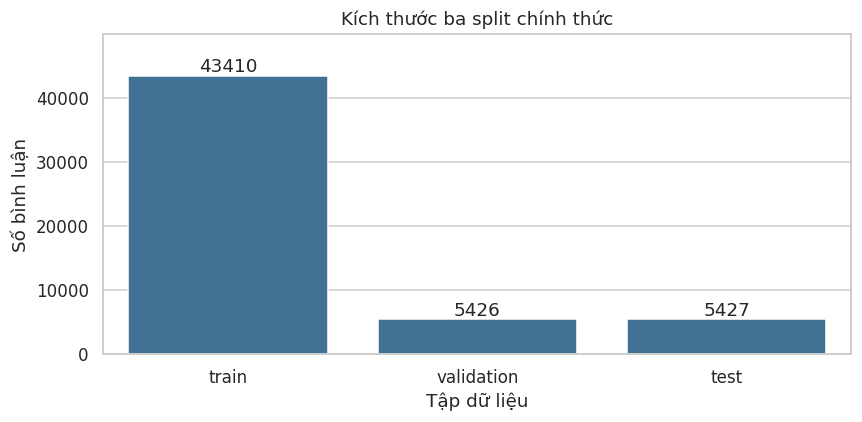

In [4]:
quality_rows = []
for split, df in frames.items():
    quality_rows.append({
        'split': split, 'n_samples': len(df),
        'missing_text': int(df.text.isna().sum()), 'missing_id': int(df.id.isna().sum()),
        'blank_text': int(df.text.str.strip().eq('').sum()),
        'empty_labels': int(df.labels.map(len).eq(0).sum()),
        'repeated_labels': int(df.labels.map(lambda v: len(v) != len(set(v))).sum()),
        'invalid_labels': int(df.labels.map(lambda v: any(not 0 <= j < 28 for j in v)).sum()),
        'unique_ids': df.id.nunique(), 'unique_texts': df.text.nunique(),
        'duplicate_id_extra_rows': int(df.id.duplicated().sum()),
        'duplicate_text_extra_rows': int(df.text.duplicated().sum())})
quality = pd.DataFrame(quality_rows)
save_table(quality, 'data_quality')
display(quality)
checks = ['missing_text','missing_id','blank_text','empty_labels','repeated_labels',
          'invalid_labels','duplicate_id_extra_rows']
assert quality[checks].to_numpy().sum() == 0, 'Có bất thường cần xem trước khi phân tích.'
split_sizes = quality[['split','n_samples']].copy()
split_sizes['percent_all_samples'] = split_sizes.n_samples / split_sizes.n_samples.sum() * 100
display(split_sizes.round(4))
save_table(split_sizes, 'split_sizes')
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=split_sizes, x='split', y='n_samples', color='#3274A1')
ax.bar_label(ax.containers[0], fmt='%d')
ax.set(xlabel='Tập dữ liệu', ylabel='Số bình luận', title='Kích thước ba split chính thức')
ax.set_ylim(0, split_sizes.n_samples.max() * 1.15)
finish_figure('01_split_sizes')

**Cách đọc:** tổng `simplified` phải là 54.263, khác khoảng 58 nghìn bình luận
được mô tả cho bộ gốc trong [bài báo ACL 2020](https://aclanthology.org/2020.acl-main.372/).
Khoảng 80%/10%/10% là split do nguồn cung cấp, không phải phép chia ngẫu nhiên mới của nhóm.

## Bước 5 — Mã hóa multi-hot và kiểm chứng

Tạo `Y` kích thước N × 28: `Y[i, j] = 1` khi mẫu i có nhãn j, còn lại bằng 0.
Tổng một hàng là số nhãn của mẫu; tổng một cột là số mẫu mang nhãn đó (support).
EDA lưu `uint8` để tiết kiệm bộ nhớ; khi huấn luyện BCE cần chuyển nhãn sang float.

In [5]:
Y = {split: multi_hot(df.labels.tolist()) for split, df in frames.items()}
for split, matrix in Y.items():
    assert matrix.shape == (len(frames[split]), 28)
    assert np.array_equal(matrix.sum(axis=1), frames[split].labels.map(len).to_numpy())
    print(split, matrix.shape, matrix.dtype)
example_i = next(i for i, labels in enumerate(frames['train'].labels) if len(labels) > 1)
display(frames['train'].iloc[[example_i]])
display(pd.DataFrame(Y['train'][[example_i]], columns=label_names))
print('Nhãn được giải mã:', [label_names[j] for j in np.flatnonzero(Y['train'][example_i])])

train (43410, 28) uint8
validation (5426, 28) uint8
test (5427, 28) uint8


,text,labels,id
7,We need more boards and to create a bit more space for [NAME]. Then we’ll be good.,"[8, 20]",ef4qmod


,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,disappointment,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0


Nhãn được giải mã: ['desire', 'optimism']


## Bước 6 — Phân bố đầy đủ 28 nhãn

Với nhãn j và split s: `support = sum(Y_s[:, j])`,
`prevalence (%) = 100 × support / số mẫu của split`.
Một mẫu đa nhãn được tính vào nhiều cột, nên **tổng tỷ lệ có thể vượt 100%**.
`share_of_assignments` có mẫu số là tổng lượt gán nhãn, là một đại lượng khác.
Notebook xuất cả hai, nhưng so sánh mức phổ biến giữa split bằng prevalence.

,label_id,label,train_count,validation_count,test_count,total_count,train_prevalence_pct
0,0,admiration,4130,488,504,5122,9.514
1,1,amusement,2328,303,264,2895,5.363
2,2,anger,1567,195,198,1960,3.610
3,3,annoyance,2470,303,320,3093,5.690
4,4,approval,2939,397,351,3687,6.770
5,5,caring,1087,153,135,1375,2.504
6,6,confusion,1368,152,153,1673,3.151
7,7,curiosity,2191,248,284,2723,5.047
8,8,desire,641,77,83,801,1.477
9,9,disappointment,1269,163,151,1583,2.923


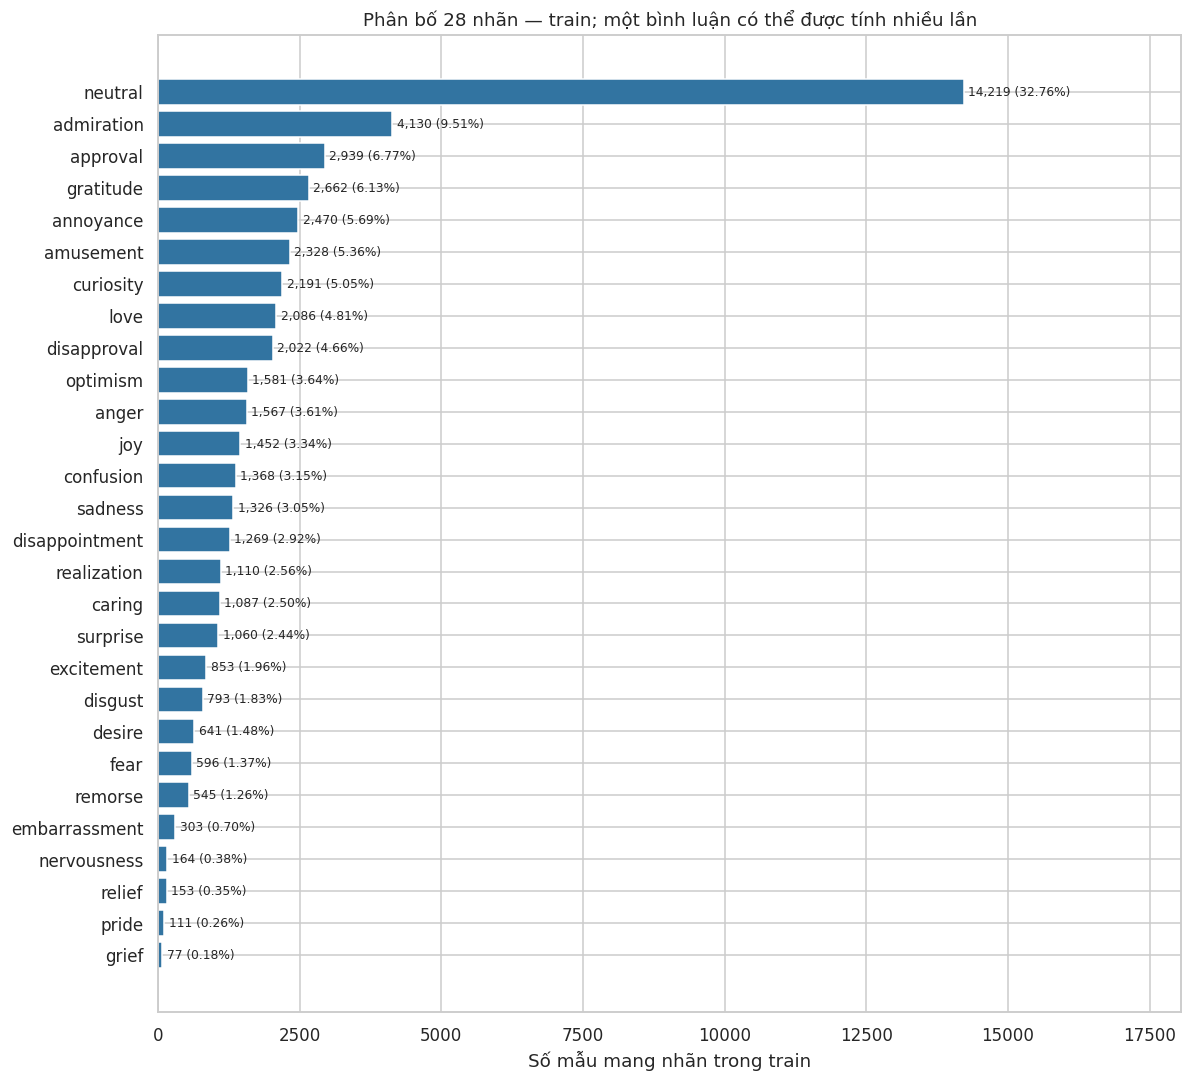

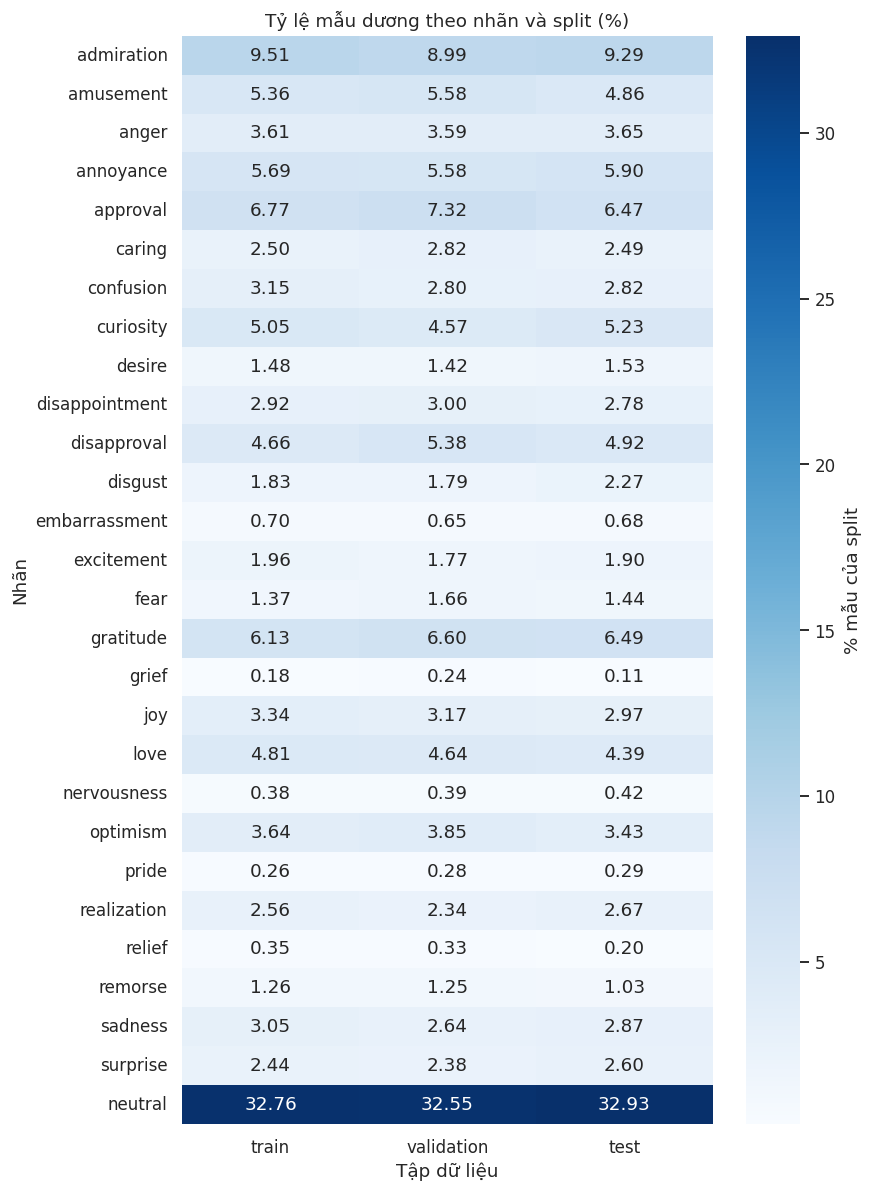

In [6]:
label_stats = label_mapping.copy()
for split in SPLITS:
    counts = Y[split].sum(axis=0).astype(int)
    label_stats[f'{split}_count'] = counts
    label_stats[f'{split}_prevalence_pct'] = counts / len(frames[split]) * 100
label_stats['total_count'] = label_stats[[f'{s}_count' for s in SPLITS]].sum(axis=1)
label_stats['total_prevalence_pct'] = label_stats.total_count / sum(map(len, frames.values())) * 100
label_stats['train_share_of_assignments_pct'] = label_stats.train_count / label_stats.train_count.sum() * 100
save_table(label_stats, 'label_distribution')
display(label_stats[['label_id','label','train_count','validation_count','test_count',
                     'total_count','train_prevalence_pct']].round(3))
ordered = label_stats.sort_values('train_count', ascending=True)
fig, ax = plt.subplots(figsize=(11, 10))
ax.barh(ordered.label, ordered.train_count, color='#3274A1')
for i, (_, row) in enumerate(ordered.iterrows()):
    ax.text(row.train_count + 80, i, f'{row.train_count:,} ({row.train_prevalence_pct:.2f}%)', va='center', fontsize=8)
ax.set(xlim=(0, ordered.train_count.max()*1.27), xlabel='Số mẫu mang nhãn trong train',
       ylabel='', title='Phân bố 28 nhãn — train; một bình luận có thể được tính nhiều lần')
finish_figure('02_label_distribution_train')
prevalence = label_stats.set_index('label')[[f'{s}_prevalence_pct' for s in SPLITS]]
prevalence.columns = list(SPLITS)
plt.figure(figsize=(8, 11))
sns.heatmap(prevalence, annot=True, fmt='.2f', cmap='Blues', cbar_kws={'label': '% mẫu của split'})
plt.title('Tỷ lệ mẫu dương theo nhãn và split (%)')
plt.xlabel('Tập dữ liệu'); plt.ylabel('Nhãn')
finish_figure('03_prevalence_by_split')

## Bước 7 — Mất cân bằng và năm nhãn hiếm

Năm nhãn hiếm được xác định **chỉ bằng train**, sắp theo support tăng dần.
Tỷ số `max support / min support` mô tả độ mất cân bằng nhưng không đo chất lượng mô hình.
Xem thêm tỷ số khi bỏ neutral để thấy sự chênh lệch giữa riêng 27 cảm xúc.

In [7]:
rare = label_stats.sort_values(['train_count','label_id']).head(5).copy()
rare_names = rare.label.tolist()
imbalance_ratio = label_stats.train_count.max() / label_stats.train_count.min()
emotions_only = label_stats[label_stats.label != 'neutral']
emotion_ratio = emotions_only.train_count.max() / emotions_only.train_count.min()
display(rare[['label','train_count','validation_count','test_count','train_prevalence_pct']].round(4))
save_table(rare, 'rare_labels_train_defined')
print(f'Tỷ số lớn nhất/nhỏ nhất (28 nhãn): {imbalance_ratio:.2f} lần')
print(f'Tỷ số lớn nhất/nhỏ nhất (27 cảm xúc): {emotion_ratio:.2f} lần')
display(Markdown('**Nhận xét:** ' + ', '.join(rare_names) +
    ' là 5 nhãn ít mẫu nhất trên train. Số mẫu ít làm việc học và đo F1 từng nhãn kém ổn định. '
    'Theo kế hoạch nhóm, cần báo Macro-F1 cùng Micro-F1 và support từng nhãn; '
    'mọi trọng số lớp phải tính trên train, mọi ngưỡng phải chọn trên validation.'))

,label,train_count,validation_count,test_count,train_prevalence_pct
16,grief,77,13,6,0.1774
21,pride,111,15,16,0.2557
23,relief,153,18,11,0.3525
19,nervousness,164,21,23,0.3778
12,embarrassment,303,35,37,0.6980


Tỷ số lớn nhất/nhỏ nhất (28 nhãn): 184.66 lần
Tỷ số lớn nhất/nhỏ nhất (27 cảm xúc): 53.64 lần


**Nhận xét:** grief, pride, relief, nervousness, embarrassment là 5 nhãn ít mẫu nhất trên train. Số mẫu ít làm việc học và đo F1 từng nhãn kém ổn định. Theo kế hoạch nhóm, cần báo Macro-F1 cùng Micro-F1 và support từng nhãn; mọi trọng số lớp phải tính trên train, mọi ngưỡng phải chọn trên validation.

## Bước 8 — Một mẫu có bao nhiêu nhãn

**Cardinality** = tổng lượt gán nhãn / số mẫu, tức số nhãn trung bình trên một bình luận.
**Density** = cardinality / 28, tức tỷ lệ ô bằng 1 trong ma trận Y.
**Tỷ lệ đa nhãn** = số mẫu có ≥2 nhãn / số mẫu. Ba đại lượng này không đồng nghĩa.

,split,n_samples,label_assignments,one_label,two_labels,three_or_more,multi_label_samples,multi_label_pct,cardinality,density,max_labels
0,train,43410,51103,36308,6541,561,7102,16.36029,1.17722,0.04204,5
1,validation,5426,6380,4548,809,69,878,16.18135,1.17582,0.04199,4
2,test,5427,6329,4590,774,63,837,15.42289,1.16621,0.04165,4


,split,n_labels,n_samples,percent
0,train,1,36308,83.640
1,train,2,6541,15.068
2,train,3,532,1.226
3,train,4,28,0.065
4,train,5,1,0.002
5,validation,1,4548,83.819
6,validation,2,809,14.910
7,validation,3,62,1.143
8,validation,4,7,0.129
9,test,1,4590,84.577


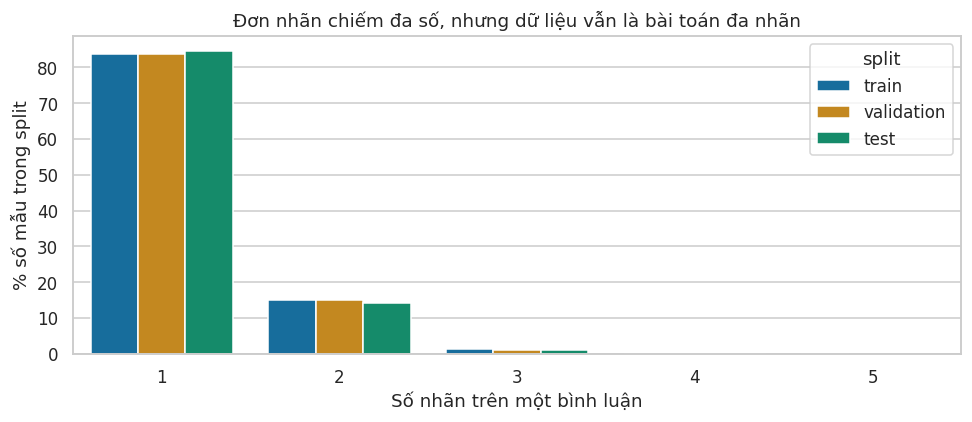

In [8]:
multi_rows, cardinality_rows = [], []
for split, df in frames.items():
    k = df.labels.map(len)
    multi_rows.append({'split': split, 'n_samples': len(df), 'label_assignments': int(k.sum()),
                      'one_label': int((k == 1).sum()), 'two_labels': int((k == 2).sum()),
                      'three_or_more': int((k >= 3).sum()), 'multi_label_samples': int((k >= 2).sum()),
                      'multi_label_pct': (k >= 2).mean()*100, 'cardinality': k.mean(),
                      'density': k.mean()/28, 'max_labels': int(k.max())})
    for n, count in k.value_counts().sort_index().items():
        cardinality_rows.append({'split': split, 'n_labels': n, 'n_samples': count, 'percent': count/len(df)*100})
multi_stats = pd.DataFrame(multi_rows)
cardinality_dist = pd.DataFrame(cardinality_rows)
display(multi_stats.round(5)); display(cardinality_dist.round(3))
save_table(multi_stats, 'multilabel_summary'); save_table(cardinality_dist, 'labels_per_sample')
plt.figure(figsize=(9, 4))
sns.barplot(data=cardinality_dist, x='n_labels', y='percent', hue='split')
plt.xlabel('Số nhãn trên một bình luận'); plt.ylabel('% số mẫu trong split')
plt.title('Đơn nhãn chiếm đa số, nhưng dữ liệu vẫn là bài toán đa nhãn')
finish_figure('04_labels_per_sample')

## Bước 9 — Neutral và các nhãn cùng xuất hiện

Tách `neutral` đứng một mình khỏi `neutral` cùng nhãn khác. Không tự đặt quy tắc
“có neutral thì xóa mọi cảm xúc”, vì sẽ thay ground truth của dữ liệu.

Với train, `C = Y.T @ Y` đếm số mẫu cùng có hai nhãn. Đường chéo là support,
không phải cặp hai nhãn khác nhau. Chuyển sang **int64 trước khi nhân** để tránh
tràn số `uint8`. Heatmap dùng log(1 + count) để thấy cả cặp phổ biến lẫn hiếm.
Jaccard = giao / hợp, nằm trong [0,1]; không phải quan hệ nhân quả hay độ giống nghĩa.

,split,neutral_total,neutral_only,neutral_with_other,neutral_with_other_pct_all
0,train,14219,12823,1396,3.216
1,validation,1766,1592,174,3.207
2,test,1787,1606,181,3.335


,label_a,label_b,count,percent_train,jaccard
14,admiration,gratitude,279,0.6427,0.0428
53,anger,annoyance,269,0.6197,0.0714
3,admiration,approval,246,0.5667,0.0361
147,confusion,curiosity,212,0.4884,0.0633
124,approval,neutral,202,0.4653,0.0119
17,admiration,love,192,0.4423,0.0319
84,annoyance,disapproval,178,0.4100,0.0413
222,disappointment,sadness,133,0.3064,0.0540
101,annoyance,neutral,132,0.3041,0.0080
16,admiration,joy,126,0.2903,0.0231


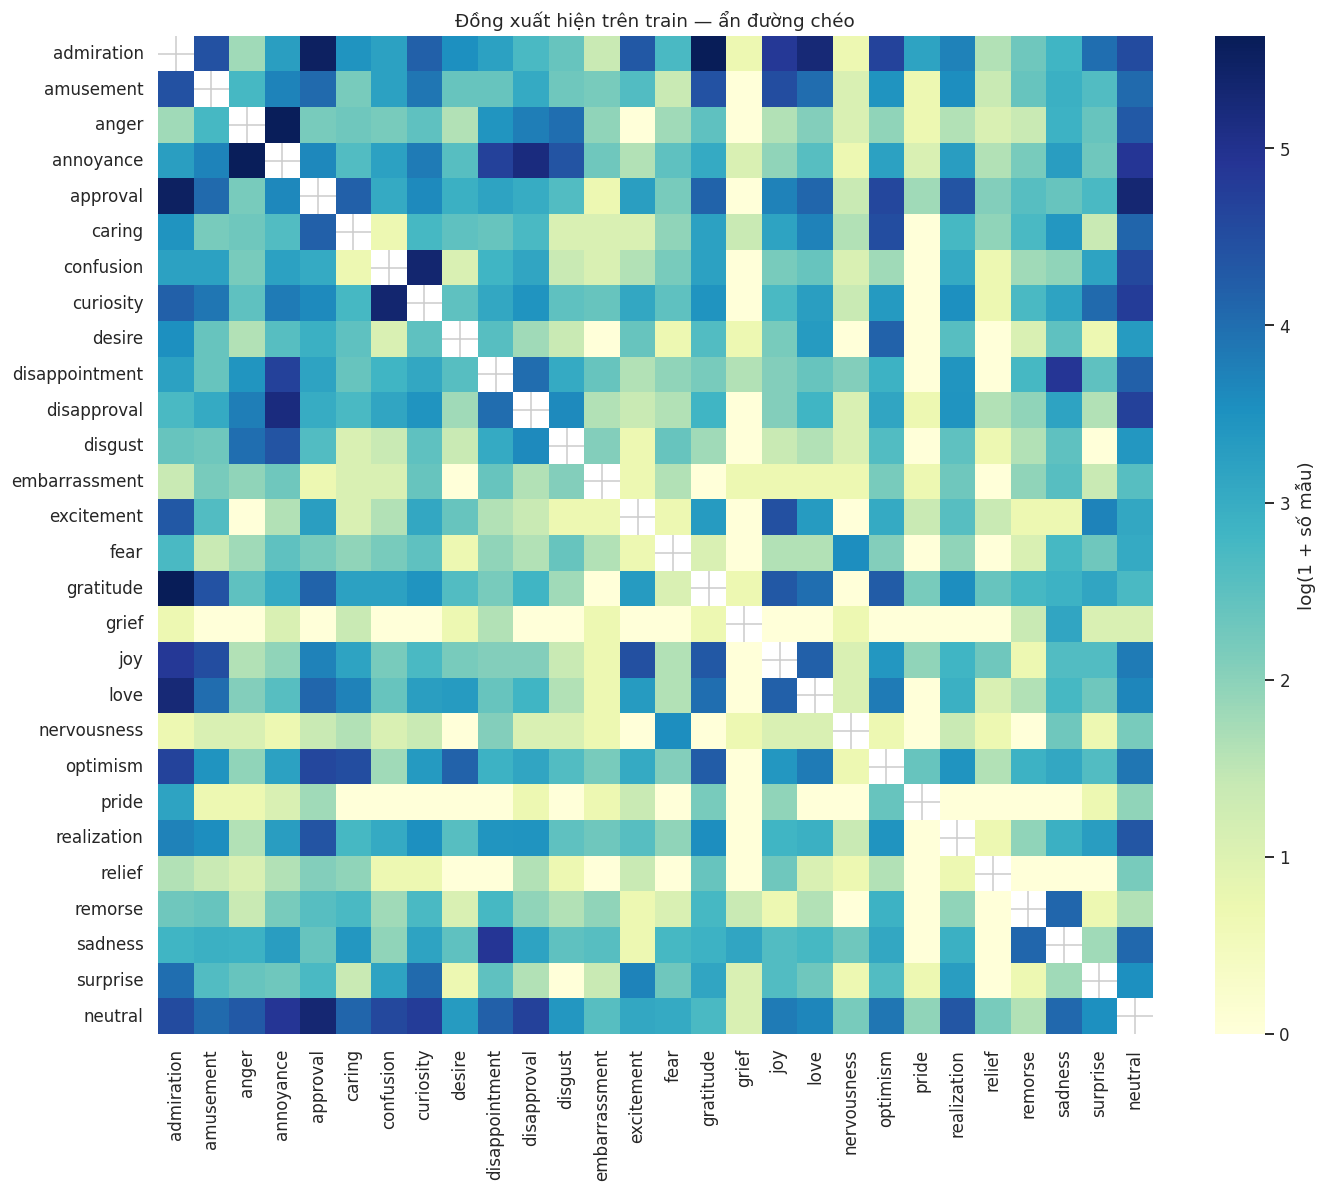

In [9]:
neutral_id = label_names.index('neutral')
neutral_rows = []
for split, matrix in Y.items():
    has_neutral = matrix[:, neutral_id].astype(bool)
    is_multi = matrix.sum(axis=1) > 1
    neutral_rows.append({'split': split, 'neutral_total': int(has_neutral.sum()),
        'neutral_only': int((has_neutral & ~is_multi).sum()),
        'neutral_with_other': int((has_neutral & is_multi).sum()),
        'neutral_with_other_pct_all': (has_neutral & is_multi).mean()*100})
neutral_stats = pd.DataFrame(neutral_rows)
display(neutral_stats.round(3)); save_table(neutral_stats, 'neutral_summary')
y64 = Y['train'].astype(np.int64)
co = y64.T @ y64
support = np.diag(co)
pairs = pd.DataFrame([
    {'label_a': label_names[a], 'label_b': label_names[b], 'count': int(co[a,b]),
     'percent_train': co[a,b]/len(y64)*100,
     'jaccard': co[a,b]/(support[a]+support[b]-co[a,b])}
    for a,b in combinations(range(28), 2)
]).sort_values(['count','label_a','label_b'], ascending=[False, True, True])
display(pairs.head(15).round(4)); save_table(pairs, 'label_cooccurrence_pairs_train')
pd.DataFrame(co, index=label_names, columns=label_names).to_csv(TABLES/'cooccurrence_matrix_train.csv', encoding='utf-8-sig')
plt.figure(figsize=(13, 11))
sns.heatmap(np.log1p(co), mask=np.eye(28, dtype=bool), cmap='YlGnBu',
            xticklabels=label_names, yticklabels=label_names, cbar_kws={'label':'log(1 + số mẫu)'})
plt.title('Đồng xuất hiện trên train — ẩn đường chéo'); plt.xticks(rotation=90); plt.yticks(rotation=0)
finish_figure('05_cooccurrence_train')

## Bước 10 — Kiểm tra trùng lặp và nguy cơ rò rỉ

Kiểm tra ID giao nhau giữa các split và text **trùng nguyên chuỗi**, phân biệt:
(1) số chuỗi khác nhau bị trùng, (2) số dòng bị ảnh hưởng ở mỗi phía.
Hai dòng có text giống nhau vẫn có thể có ID và nhãn khác nhau.

Kiểm tra thêm chuẩn hóa nhẹ `casefold + gộp khoảng trắng` là phép chẩn đoán riêng,
không phải bằng chứng hai bản ghi có cùng nguồn gốc, không thay đổi dữ liệu gốc.
Không đủ metadata trong simplified để kết luận trùng tác giả hoặc cùng cuộc hội thoại.

In [10]:
overlap_rows = []
for a,b in combinations(SPLITS, 2):
    left, right = frames[a], frames[b]
    id_overlap = set(left.id) & set(right.id)
    exact = set(left.text) & set(right.text)
    normalize = lambda s: s.str.casefold().str.replace(r'\s+', ' ', regex=True).str.strip()
    ln, rn = normalize(left.text), normalize(right.text)
    norm_overlap = set(ln) & set(rn)
    overlap_rows.append({'left_split': a, 'right_split': b, 'shared_ids': len(id_overlap),
        'shared_exact_texts': len(exact), 'left_rows_exact': int(left.text.isin(exact).sum()),
        'right_rows_exact': int(right.text.isin(exact).sum()),
        'shared_normalized_texts': len(norm_overlap), 'right_rows_normalized': int(rn.isin(norm_overlap).sum())})
overlap = pd.DataFrame(overlap_rows)
assert overlap.shared_ids.sum() == 0
display(overlap); save_table(overlap, 'cross_split_overlap')
duplicate_rows = []
for split, df in frames.items():
    temp = df.assign(label_set=df.labels.map(lambda x: tuple(sorted(x))))
    groups = temp.groupby('text').agg(n_rows=('id','size'), n_label_sets=('label_set','nunique'))
    duplicate_rows.append({'split': split, 'duplicate_text_groups': int((groups.n_rows > 1).sum()),
        'rows_in_duplicate_groups': int(groups.loc[groups.n_rows > 1,'n_rows'].sum()),
        'duplicate_extra_rows': len(df)-len(groups),
        'duplicate_groups_with_different_labels': int(((groups.n_rows > 1)&(groups.n_label_sets > 1)).sum())})
duplicates = pd.DataFrame(duplicate_rows)
display(duplicates); save_table(duplicates, 'within_split_duplicates')
test_not_in_train = ~frames['test'].text.isin(set(frames['train'].text))
clean_test_ids = frames['test'].loc[test_not_in_train, ['id']]
save_table(clean_test_ids, 'test_ids_without_exact_train_overlap')
print('Test chính giữ nguyên:', len(frames['test']))
print('Test phân tích độ nhạy, loại text trùng train:', len(clean_test_ids))
print('Danh sách trên chưa loại text trùng validation; không gọi đây là tập hoàn toàn độc lập.')

,left_split,right_split,shared_ids,shared_exact_texts,left_rows_exact,right_rows_exact,shared_normalized_texts,right_rows_normalized
0,train,validation,0,41,84,43,46,49
1,train,test,0,32,79,37,37,42
2,validation,test,0,10,10,13,11,14


,split,duplicate_text_groups,rows_in_duplicate_groups,duplicate_extra_rows,duplicate_groups_with_different_labels
0,train,118,301,183,58
1,validation,2,5,3,1
2,test,5,11,6,1


Test chính giữ nguyên: 5427
Test phân tích độ nhạy, loại text trùng train: 5390
Danh sách trên chưa loại text trùng validation; không gọi đây là tập hoàn toàn độc lập.


## Bước 11 — Độ dài văn bản

Đếm ký tự bằng `len(text)` (Unicode code points) và “từ” bằng `text.split()`
(đơn vị cách nhau bởi khoảng trắng). Đây là hai phép mô tả đơn giản,
**không phải số subword token** của BERT/RoBERTa.
P50 là trung vị; P95/P99 cho biết vùng đuôi của phân bố, không chứng minh rằng
chọn đúng mốc đó là cấu hình tối ưu.

,split,measure,min,mean,std,p50,p90,p95,p99,max
0,train,n_chars,2,68.40,36.72,65.0,120.0,131.00,151.0,703
1,train,n_words_whitespace,1,12.84,6.70,12.0,22.0,24.00,27.0,33
2,validation,n_chars,5,68.24,36.91,64.0,121.0,133.00,152.0,187
3,validation,n_words_whitespace,1,12.79,6.74,12.0,23.0,24.75,27.0,30
4,test,n_chars,5,67.82,36.32,65.0,119.0,132.00,148.0,184
5,test,n_words_whitespace,1,12.73,6.67,12.0,22.0,24.00,27.0,32


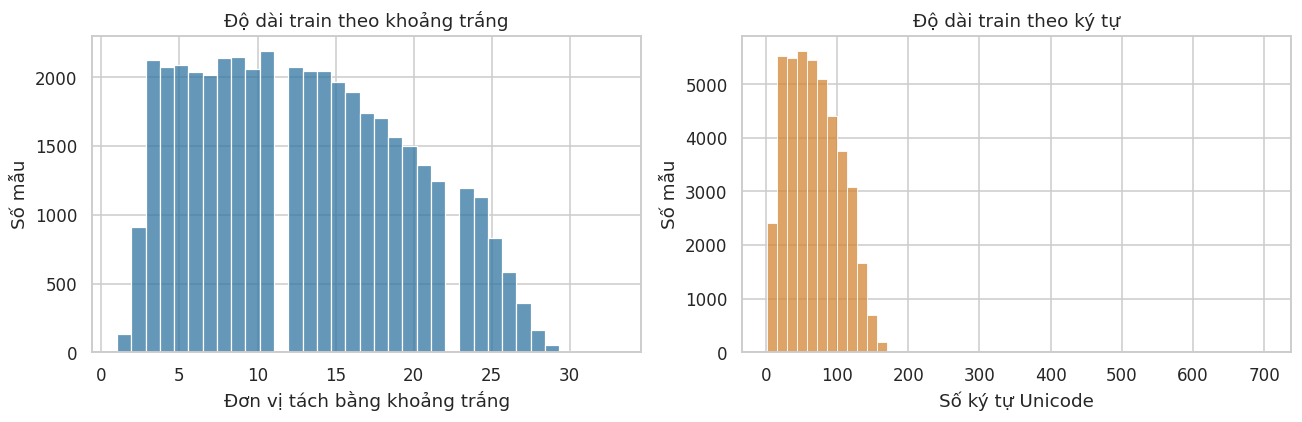

**Lưu ý:** giữ dấu câu, chữ hoa, emoji và phủ định trong dữ liệu gốc. Chưa chọn `max_length` từ số từ; bước kế tiếp đo đúng tokenizer.

In [11]:
length_frames, length_rows = {}, []
for split, df in frames.items():
    lengths = pd.DataFrame({'id': df.id, 'n_chars': df.text.str.len(),
                             'n_words_whitespace': df.text.str.split().str.len()})
    length_frames[split] = lengths
    for feature in ['n_chars','n_words_whitespace']:
        values = lengths[feature]
        length_rows.append({'split': split, 'measure': feature, 'min': values.min(),
            'mean': values.mean(), 'std': values.std(), 'p50': values.quantile(.5),
            'p90': values.quantile(.9), 'p95': values.quantile(.95),
            'p99': values.quantile(.99), 'max': values.max()})
length_summary = pd.DataFrame(length_rows)
display(length_summary.round(2)); save_table(length_summary, 'text_length_summary')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(length_frames['train'].n_words_whitespace, bins=35, ax=axes[0], color='#3274A1')
axes[0].set(xlabel='Đơn vị tách bằng khoảng trắng', ylabel='Số mẫu', title='Độ dài train theo khoảng trắng')
sns.histplot(length_frames['train'].n_chars, bins=50, ax=axes[1], color='#D48433')
axes[1].set(xlabel='Số ký tự Unicode', ylabel='Số mẫu', title='Độ dài train theo ký tự')
finish_figure('06_text_lengths_train')
display(Markdown('**Lưu ý:** giữ dấu câu, chữ hoa, emoji và phủ định trong dữ liệu gốc. '
    'Chưa chọn `max_length` từ số từ; bước kế tiếp đo đúng tokenizer.'))

## Bước 12 — Độ dài theo tokenizer của ba kiến trúc

Đọc `tokenizer.json` chính thức của BERT-base-uncased, RoBERTa-base và DistilBERT-base-uncased,
ghim commit trong `data/tokenizer_revisions.json`. Dùng thư viện Rust-backed `tokenizers`;
chỉ tải tokenizer, không tải trọng số. Cấu hình mặc định cho **một văn bản**,
`add_special_tokens=True`, không padding/truncation khi đo.

Ví dụ BERT có `[CLS]` và `[SEP]`, nên số token đã gồm các token đặc biệt.
Báo tỷ lệ `length > max_length` tại 64/128/256 và số token sẽ bị cắt.
Đo trên **train và validation**; không dùng test để ra quyết định độ dài.
BERT và DistilBERT có thể trùng kết quả vì dùng cùng cách tách từ; đây không phải lỗi.
Khi chuyển sang Transformers, giữ đúng revision/default và kiểm tra lại nếu thay cấu hình tokenizer.

,tokenizer,split,n_samples,mean,p50,p95,p99,max
0,BERT,train,43410,19.171,19.0,34.0,38.0,316
1,BERT,validation,5426,19.123,19.0,34.0,38.0,48
2,RoBERTa,train,43410,18.910,18.0,33.0,37.0,1437
3,RoBERTa,validation,5426,18.827,18.0,33.0,38.0,73
4,DistilBERT,train,43410,19.171,19.0,34.0,38.0,316
5,DistilBERT,validation,5426,19.123,19.0,34.0,38.0,48


,tokenizer,split,max_length,samples_truncated,percent_truncated,tokens_removed
0,BERT,train,64,3,0.00691,321
1,BERT,train,128,1,0.00230,188
2,BERT,train,256,1,0.00230,60
3,BERT,validation,64,0,0.00000,0
4,BERT,validation,128,0,0.00000,0
5,BERT,validation,256,0,0.00000,0
6,RoBERTa,train,64,10,0.02304,1972
7,RoBERTa,train,128,4,0.00921,1642
8,RoBERTa,train,256,2,0.00461,1245
9,RoBERTa,validation,64,1,0.01843,9


,tokenizer,id,n_tokens,n_chars,n_words_whitespace,text_preview
0,BERT,edwy61c,316,514,32,here you go: |Games|Home|Away|Team|vs W-L 18-19| |:-|:-|:-|:-|-:| |1|1|0|Golden State|0-1| |2|1|1|Ho…
1,BERT,ee4as4o,115,198,18,"ackchyually, it's *r/woooosh ^^^^^I'm ^^^^^a ^^^^^bot. ^^^^^Complaints ^^^^^should ^^^^^be ^^^^^sent…"
2,BERT,ef9of3l,82,93,4,Oh fuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuck RIGHT OFF!!!!!
3,RoBERTa,ef0rf7q,1437,542,26,For your kindness to mobile users I give a platinum ⠀⠀⠀⠀⠀⣤⣶⣶⡶⠦⠴⠶⠶⠶⠶⡶⠶⠦⠶⠶⠶⠶⠶⠶⠶⣄⠀⠀⠀⠀ ⠀⠀⠀⠀⠀⣿⣀⣀⣀⣀⠀⢀⣤⠄⠀⠀⣶…
4,RoBERTa,edwy61c,320,514,32,here you go: |Games|Home|Away|Team|vs W-L 18-19| |:-|:-|:-|:-|-:| |1|1|0|Golden State|0-1| |2|1|1|Ho…
5,RoBERTa,eds3a07,211,400,23,No the whippet sound is WUBWUBWUBWUBWUBWUBWUBWUBWUBWUBWUBWUBWUBWUBWUBWUBWUBWUBWUBWUBWUBWUBWUBWUBWUBW…
6,DistilBERT,edwy61c,316,514,32,here you go: |Games|Home|Away|Team|vs W-L 18-19| |:-|:-|:-|:-|-:| |1|1|0|Golden State|0-1| |2|1|1|Ho…
7,DistilBERT,ee4as4o,115,198,18,"ackchyually, it's *r/woooosh ^^^^^I'm ^^^^^a ^^^^^bot. ^^^^^Complaints ^^^^^should ^^^^^be ^^^^^sent…"
8,DistilBERT,ef9of3l,82,93,4,Oh fuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuuck RIGHT OFF!!!!!


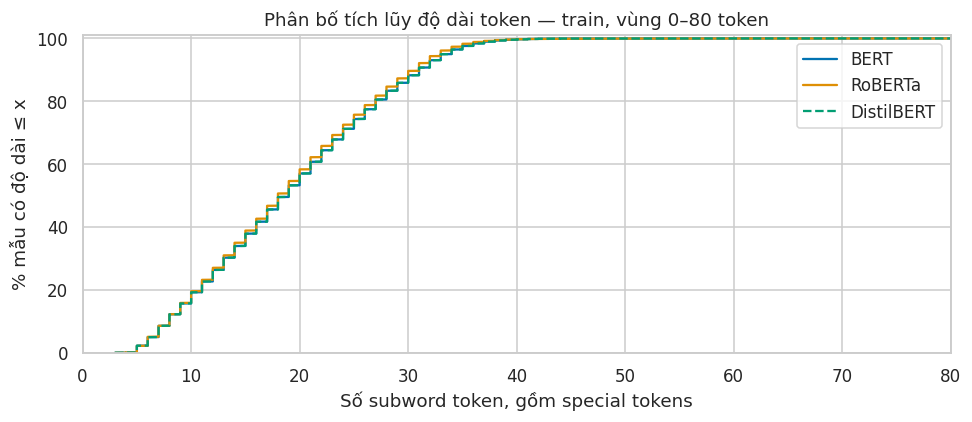

**Diễn giải:** 128 là ứng viên khởi đầu của kế hoạch. Bảng trên cho biết bao nhiêu mẫu sẽ bị cắt, chưa cho biết ảnh hưởng tới F1. Biểu đồ phóng vùng 0–80 token; các mẫu dài hơn vẫn có trong bảng và phép đếm. Chuỗi Unicode/emoji hoặc ký tự lặp có thể dài sau subword tokenization dù ít khoảng trắng. Chốt cấu hình sau pilot trên train/validation và giữ cố định trước đánh giá test.

In [12]:
from tokenizers import Tokenizer
tokenizer_revisions = json.loads((ROOT/'data/tokenizer_revisions.json').read_text(encoding='utf-8'))
token_rows, tokenizer_manifest, token_lengths = [], [], {}
for model_id, revision in tokenizer_revisions.items():
    model_short = {'google-bert/bert-base-uncased':'BERT', 'FacebookAI/roberta-base':'RoBERTa',
                   'distilbert/distilbert-base-uncased':'DistilBERT'}[model_id]
    url = f'https://huggingface.co/{model_id}/resolve/{revision}/tokenizer.json'
    path = download(url, ROOT/'data/tokenizers'/model_short/revision/'tokenizer.json')
    tok = Tokenizer.from_file(str(path))
    tok.no_truncation(); tok.no_padding()
    tokenizer_manifest.append({'name': model_short, 'model_id': model_id, 'revision': revision,
        'url': url, 'sha256': sha256(path), 'special_tokens_included': True})
    for split in ['train','validation']:
        texts = frames[split].text.tolist()
        counts = []
        for start in range(0, len(texts), 512):
            counts.extend(len(enc.ids) for enc in tok.encode_batch(texts[start:start+512], add_special_tokens=True))
        values = np.asarray(counts)
        token_lengths[(model_short, split)] = values
        row = {'tokenizer': model_short, 'split': split, 'n_samples': len(values),
               'mean': values.mean(), 'p50': np.quantile(values,.5), 'p95': np.quantile(values,.95),
               'p99': np.quantile(values,.99), 'max': int(values.max())}
        for limit in [64,128,256]:
            row[f'over_{limit}_count'] = int((values > limit).sum())
            row[f'over_{limit}_pct'] = (values > limit).mean()*100
            row[f'tokens_removed_at_{limit}'] = int(np.maximum(values-limit, 0).sum())
        token_rows.append(row)
token_summary = pd.DataFrame(token_rows)
save_table(token_summary, 'tokenizer_lengths_train_validation')
(ROOT/'data/tokenizer_manifest.json').write_text(json.dumps(tokenizer_manifest, indent=2), encoding='utf-8')
display(token_summary[['tokenizer','split','n_samples','mean','p50','p95','p99','max']].round(3))
truncation = pd.DataFrame([
    {'tokenizer': row['tokenizer'], 'split': row['split'], 'max_length': limit,
     'samples_truncated': row[f'over_{limit}_count'], 'percent_truncated': row[f'over_{limit}_pct'],
     'tokens_removed': row[f'tokens_removed_at_{limit}']}
    for row in token_rows for limit in [64,128,256]])
save_table(truncation, 'tokenizer_truncation')
display(truncation.round(5))
outlier_rows = []
for name in ['BERT','RoBERTa','DistilBERT']:
    values = token_lengths[(name,'train')]
    for i in np.argsort(values, kind='stable')[-3:][::-1]:
        row = frames['train'].iloc[i]
        outlier_rows.append({'tokenizer': name, 'id': row.id, 'n_tokens': int(values[i]),
            'n_chars': len(row.text), 'n_words_whitespace': len(row.text.split()),
            'text_preview': row.text[:100] + ('…' if len(row.text)>100 else '')})
token_outliers = pd.DataFrame(outlier_rows)
save_table(token_outliers, 'tokenizer_outliers_train')
display(token_outliers)
fig, ax = plt.subplots(figsize=(9, 4))
for name in ['BERT','RoBERTa','DistilBERT']:
    values = token_lengths[(name,'train')]
    xs = np.sort(values)
    ax.plot(xs, np.arange(1,len(xs)+1)/len(xs)*100, label=name,
            linestyle='--' if name == 'DistilBERT' else '-')
ax.set(xlabel='Số subword token, gồm special tokens', ylabel='% mẫu có độ dài ≤ x',
       title='Phân bố tích lũy độ dài token — train, vùng 0–80 token', ylim=(0,101), xlim=(0,80))
ax.legend(); finish_figure('07_token_length_ecdf_train')
display(Markdown('**Diễn giải:** 128 là ứng viên khởi đầu của kế hoạch. Bảng trên cho biết '
    'bao nhiêu mẫu sẽ bị cắt, chưa cho biết ảnh hưởng tới F1. '
    'Biểu đồ phóng vùng 0–80 token; các mẫu dài hơn vẫn có trong bảng và phép đếm. '
    'Chuỗi Unicode/emoji hoặc ký tự lặp có thể dài sau subword tokenization dù ít khoảng trắng. '
    'Chốt cấu hình sau pilot trên train/validation và giữ cố định trước đánh giá test.'))

## Bước 13 — Ba mươi ví dụ từ train để nhóm xem thủ công

Chọn có chủ đích 28 ví dụ (mỗi nhãn một ví dụ) và thêm một mẫu ≥3 nhãn,
một mẫu neutral kèm cảm xúc. Ưu tiên 3–20 đơn vị khoảng trắng và đơn nhãn nếu có;
sắp theo ID rồi lấy mẫu với seed 42. Các ID không lặp, nguyên văn không bị sửa.
Đây là **bộ minh họa phủ nhãn**, không phải mẫu ngẫu nhiên đại diện để ước lượng tỷ lệ.

`selection_reason` giải thích cách chọn, không phải giải thích đúng/sai của nhãn.
Cột `group_review_note` để nhóm bổ sung nhận xét riêng. Nếu có file
`references/example_notes.json`, notebook ghép thêm ghi chú đọc nội dung của người chuẩn bị;
những ghi chú này là diễn giải, không thay ground truth hoặc chứng nhận nhãn đúng.

In [13]:
train = frames['train']
used, example_rows = set(), []
def choose_example(mask, reason, prefer_single=False):
    candidates = train.loc[mask & ~train.id.isin(used)].copy()
    words = candidates.text.str.split().str.len()
    short = candidates.loc[words.between(3,20)]
    if len(short):
        candidates = short
    if prefer_single:
        single = candidates.loc[candidates.labels.map(len).eq(1)]
        if len(single):
            candidates = single
    row = candidates.sort_values('id').sample(n=1, random_state=SEED).iloc[0]
    used.add(row.id)
    example_rows.append({'split':'train', 'id':row.id, 'text':row.text,
        'label_ids': ','.join(map(str,row.labels)),
        'labels': ', '.join(label_names[j] for j in row.labels),
        'n_labels': len(row.labels), 'selection_reason': reason, 'group_review_note':''})
for j, name in enumerate(label_names):
    choose_example(train.labels.map(lambda labels: j in labels), f'Minh họa nhãn {name}', prefer_single=True)
choose_example(train.labels.map(len).ge(3), 'Minh họa một bình luận có ít nhất 3 nhãn')
choose_example(train.labels.map(lambda labels: neutral_id in labels and len(labels)>1), 'Neutral cùng cảm xúc khác')
examples = pd.DataFrame(example_rows)
notes_path = ROOT/'references/example_notes.json'
notes = json.loads(notes_path.read_text(encoding='utf-8')) if notes_path.exists() else {}
examples['reading_note'] = examples.id.map(notes).fillna('')
assert len(examples) == examples.id.nunique() == 30
assert set(range(28)) == {int(j) for value in examples.label_ids for j in value.split(',')}
save_table(examples, 'examples_30')
with pd.option_context('display.max_colwidth', None, 'display.max_rows', 40):
    display(examples[['id','text','labels','reading_note']])
display(Markdown('**Cách thảo luận:** câu có từ chỉ cảm xúc rõ hay cần ngữ cảnh? '
    'Có phủ định, hàm ý, nhãn gần nghĩa, hoặc neutral đồng xuất hiện không? '
    'Nhóm ghi nhận xét vào một bản sao của CSV để lần chạy lại không ghi đè phần ghi chú.'))

,id,text,labels,reading_note
0,efajo6t,Lol alright dude. Nice chat.,admiration,Cụm Nice chat có thể là lời khen hoặc lời kết mỉa mai tùy ngữ cảnh. Dữ liệu gán admiration; chỉ câu riêng lẻ chưa đủ xác nhận sắc thái.
1,eey5g23,Why would [NAME] even care lol Reminds me of that [NAME] [NAME] I see a lot,amusement,"Dấu hiệu lol gợi sắc thái thích thú. [NAME] là phần được che trong nguồn, không nên xóa hoặc đoán tên thật."
2,edko6gj,Screaming at this reply,anger,Screaming là phản ứng mạnh nhưng cũng có thể chỉ cười hoặc bất ngờ trên mạng. Nhãn anger cần ngữ cảnh của reply để hiểu chắc hơn.
3,eeof8t8,"I just want to shake her by her shoulders and be like ""*Why are you like this?!*""",annoyance,"Câu hỏi Why are you like this?! cùng ý muốn lay vai diễn tả bực bội, phù hợp cách đọc annoyance."
4,effjfum,Trolls are okay in this sub but let's be more serious here,approval,"Vế Trolls are okay thể hiện chấp nhận, trong khi vế sau yêu cầu nghiêm túc hơn. Cần đọc cả hai vế khi xem nhãn approval."
5,eegojhf,[NAME] it’s ok the trumpet player can’t hurt you anymore,caring,"Cấu trúc it’s ok và can’t hurt you anymore là lời trấn an, gợi caring; vẫn có khả năng đùa tùy hội thoại."
6,efckxje,New to the area. I would think it's due to the cold. I havent seen my neighborhood this dark.,confusion,"Người viết chưa quen khu vực và đang phỏng đoán nguyên nhân, tạo cảm giác chưa rõ tình hình; nhãn confusion không cần từ confused xuất hiện."
7,eelvbdz,Really? I was in New York last week and had to stand in the freezing cold to pump gas twice.,curiosity,"Really? mở đầu bằng phản ứng hỏi lại, nhưng câu cũng nêu trải nghiệm trái với thông tin trước. Curiosity cần phân biệt với surprise hoặc disapproval."
8,edjsvk7,I wish I could make a garden,desire,"I wish I could là dấu hiệu trực tiếp của mong muốn, giúp minh họa desire khá rõ."
9,efdel1c,"While out at the beach for a weekend for her birthday. There was no final straw, I just wanted to.",disappointment,"Câu bị tách khỏi câu chuyện trước đó, không có dấu hiệu disappointment rõ trong đoạn riêng. Giữ nhãn gốc và ghi nhận thiếu ngữ cảnh."


**Cách thảo luận:** câu có từ chỉ cảm xúc rõ hay cần ngữ cảnh? Có phủ định, hàm ý, nhãn gần nghĩa, hoặc neutral đồng xuất hiện không? Nhóm ghi nhận xét vào một bản sao của CSV để lần chạy lại không ghi đè phần ghi chú.

## Bước 14 — Đối chiếu số đo với file kế hoạch

Các hằng số dưới đây được chép từ bảng mục 4 và Phụ lục A để làm **mốc kiểm chứng**,
không dùng thay phép đếm. Nếu dữ liệu, mapping hoặc thuật toán sai, ô này dừng.
Đối chiếu toàn bộ 28 support của từng split, số mẫu theo số nhãn, neutral và trùng text.

In [14]:
expected_counts = {
 'train':[4130,2328,1567,2470,2939,1087,1368,2191,641,1269,2022,793,303,853,596,2662,77,1452,2086,164,1581,111,1110,153,545,1326,1060,14219],
 'validation':[488,303,195,303,397,153,152,248,77,163,292,97,35,96,90,358,13,172,252,21,209,15,127,18,68,143,129,1766],
 'test':[504,264,198,320,351,135,153,284,83,151,267,123,37,103,78,352,6,161,238,23,186,16,145,11,56,156,141,1787]}
for split in SPLITS:
    np.testing.assert_array_equal(Y[split].sum(axis=0), expected_counts[split])
np.testing.assert_array_equal(multi_stats.one_label, [36308,4548,4590])
np.testing.assert_array_equal(multi_stats.two_labels, [6541,809,774])
np.testing.assert_array_equal(multi_stats.three_or_more, [561,69,63])
np.testing.assert_array_equal(neutral_stats.neutral_with_other, [1396,174,181])
np.testing.assert_array_equal(quality.unique_texts, [43227,5423,5421])
np.testing.assert_array_equal(overlap.shared_exact_texts, [41,32,10])
np.testing.assert_array_equal(overlap.right_rows_exact, [43,37,13])
assert rare_names == ['grief','pride','relief','nervousness','embarrassment']
assert len(clean_test_ids) == 5390
verification = {'status':'passed', 'dataset_revision': REVISION,
                'checks':['sha256_3_files','schema_and_label_mapping','split_sizes','supports_28x3',
                          'label_cardinality','neutral_cooccurrence','duplicate_text','multi_hot','30_examples']}
(ROOT/'reports/verification.json').write_text(json.dumps(verification, indent=2), encoding='utf-8')
print('PASS: số liệu tính trực tiếp khớp toàn bộ các mốc EDA trong kế hoạch.')

PASS: số liệu tính trực tiếp khớp toàn bộ các mốc EDA trong kế hoạch.


## Bước 15 — Xuất kết quả để bàn giao

Xuất `Y_train/Y_validation/Y_test` và ID theo đúng thứ tự trong file `.npz`.
File này dành cho bước mô hình sau; `.npz` không chứa văn bản, phải đối chiếu ID với raw.
Xuất bảng CSV UTF-8 BOM để Excel đọc tiếng Việt, ảnh PNG và báo cáo Markdown.
Tất cả số liệu trong báo cáo dưới đây được lấy từ biến đã tính, tránh gõ lại nhầm.

In [15]:
for split in SPLITS:
    np.savez_compressed(ROOT/'data/processed'/f'{split}_multihot.npz',
                        Y=Y[split], ids=frames[split].id.to_numpy(dtype=str),
                        label_names=np.asarray(label_names, dtype=str))
    saved = np.load(ROOT/'data/processed'/f'{split}_multihot.npz', allow_pickle=False)
    assert np.array_equal(saved['Y'], Y[split])
    assert saved['ids'].tolist() == frames[split].id.tolist()
    assert saved['label_names'].tolist() == label_names

total_samples = sum(map(len, frames.values()))
total_multi = int(multi_stats.multi_label_samples.sum())
total_assignments = int(multi_stats.label_assignments.sum())
summary = {'samples': total_samples, 'n_labels': len(label_names),
           'label_assignments': total_assignments, 'multi_label_samples': total_multi,
           'multi_label_pct': total_multi/total_samples*100,
           'cardinality': total_assignments/total_samples,
           'density': total_assignments/(total_samples*28),
           'train_imbalance_ratio': float(imbalance_ratio),
           'rare_labels': rare_names, 'neutral_with_other': int(neutral_stats.neutral_with_other.sum()),
           'test_without_exact_train_overlap': len(clean_test_ids)}
(ROOT/'reports/summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')

sections = [
 '# Thống kê dữ liệu đã khám phá của đồ án GoEmotions',
 '## 1. Phạm vi và nguồn dữ liệu',
 'Phần thống kê phục vụ đề tài **Phân loại cảm xúc đa nhãn trên văn bản mạng xã hội với GoEmotions**. '
 'Sử dụng cấu hình simplified, bình luận tiếng Anh trên Reddit, 27 cảm xúc cùng neutral. '
 'Một bình luận có thể có nhiều nhãn. Ngôn ngữ thực hiện là Python; công cụ gồm pandas, NumPy, '
 'PyArrow, Matplotlib, Seaborn, Hugging Face Tokenizers và Jupyter. Chạy CPU, không cần GPU.',
 f'Revision được ghim: `{REVISION}`. Các số liệu dưới đây tính trực tiếp từ ba tệp Parquet '
 'và đã đối chiếu SHA-256 trong file kế hoạch. Phạm vi yêu cầu giảng viên được đọc qua '
 '`KE_HOACH_A_Z_DE_TAI_01_GOEMOTIONS.docx`; chưa truy cập trực tiếp được PDF SharePoint gốc.',
 'Nguồn: [Google Research README](https://github.com/google-research/google-research/blob/master/goemotions/README.md), '
 '[dataset card](https://huggingface.co/datasets/google-research-datasets/go_emotions), '
 '[bài báo ACL 2020](https://aclanthology.org/2020.acl-main.372/). '
 'Không nhầm khoảng 58 nghìn bình luận của bộ gốc với 54.263 mẫu trong simplified.',
 '## 2. Số mẫu và cấu trúc',
 split_sizes.round(4).to_markdown(index=False),
 'Mỗi dòng có `id` (mã bình luận), `text` (nguyên văn) và `labels` (danh sách ID nhãn từ 0 đến 27). '
 'Giữ nguyên split chính thức. ID không trùng giữa các split; không có text thiếu hoặc rỗng, '
 'không có tập nhãn rỗng hoặc nhãn ngoài miền.',
 '![Số mẫu](figures/01_split_sizes.png)',
 '## 3. Phân bố nhãn và mất cân bằng',
 'Support là số bình luận mang nhãn. Một dòng đa nhãn được tính vào nhiều nhãn; '
 'tổng support có thể lớn hơn số mẫu. Prevalence (%) = support / số mẫu của split × 100.',
 label_stats[['label_id','label','dien_giai_vi','train_count','validation_count','test_count',
              'total_count','train_prevalence_pct']].round(3).to_markdown(index=False),
 f'Train có tỷ số support nhãn phổ biến nhất/hiếm nhất bằng **{imbalance_ratio:.2f} lần**; '
 f'nếu chỉ xét 27 cảm xúc, tỷ số là **{emotion_ratio:.2f} lần**. '
 'Năm nhãn hiếm chỉ xác định từ train để không dùng test định hướng thí nghiệm:',
 rare[['label','train_count','validation_count','test_count']].to_markdown(index=False),
 'Neutral phổ biến nhất nhưng không nên chỉ dự đoán neutral. Theo kế hoạch, báo Macro-F1 '
 'làm chỉ số chính, kèm Micro-F1 và F1/support từng nhãn; chú ý độ bất ổn ở nhãn hiếm.',
 '![Phân bố train](figures/02_label_distribution_train.png)',
 '![Tỷ lệ theo split](figures/03_prevalence_by_split.png)',
 '## 4. Đặc tính đa nhãn',
 multi_stats.round(5).to_markdown(index=False),
 f'Toàn bộ dữ liệu có **{total_assignments:,} lượt gán nhãn**, **{total_multi:,} mẫu đa nhãn '
 f'({total_multi/total_samples*100:.2f}%)**, cardinality **{total_assignments/total_samples:.4f}** '
 f'và density **{total_assignments/(total_samples*28):.5f}**. '
 'Cardinality là số nhãn trung bình/mẫu; density là tỷ lệ ô 1 trong ma trận N × 28.',
 '![Số nhãn mỗi mẫu](figures/04_labels_per_sample.png)',
 neutral_stats.round(4).to_markdown(index=False),
 'Neutral có thể cùng xuất hiện với cảm xúc khác. Giữ nguyên ground truth; không dùng softmax '
 'để ép các lớp loại trừ nhau trong bài toán này. Các cặp đồng xuất hiện nhiều nhất trên train:',
 pairs.head(10).round(4).to_markdown(index=False),
 'Jaccard = số mẫu cùng có hai nhãn / số mẫu có ít nhất một trong hai nhãn. '
 'Đồng xuất hiện là quan hệ thống kê, không khẳng định hai cảm xúc giống nghĩa hay có quan hệ nhân quả.',
 '![Đồng xuất hiện](figures/05_cooccurrence_train.png)',
 '## 5. Chất lượng và trùng lặp',
 quality.to_markdown(index=False), duplicates.to_markdown(index=False), overlap.to_markdown(index=False),
 'Có 32 chuỗi trùng nguyên văn giữa train và test, ảnh hưởng 37 dòng test. '
 'Báo cáo benchmark chính giữ đủ 5.427 dòng test; phân tích độ nhạy dùng 5.390 dòng '
 'không trùng text với train. Danh sách này chưa loại các dòng trùng validation và không '
 'bảo đảm hết mọi dạng rò rỉ ngữ nghĩa. Phép chuẩn hóa nhẹ chỉ là chẩn đoán bổ sung. '
 'Không thể kết luận trùng người viết/cuộc hội thoại chỉ từ ba cột simplified.',
 '## 6. Độ dài văn bản và tokenizer',
 length_summary.round(2).to_markdown(index=False),
 'Ký tự được đếm theo Unicode code points; từ ở bảng trên chỉ là đơn vị cách nhau bởi khoảng trắng. '
 'Hai thước đo này khác subword token của mô hình.',
 '![Độ dài văn bản](figures/06_text_lengths_train.png)',
 token_summary[['tokenizer','split','n_samples','mean','p50','p95','p99','max']].round(3).to_markdown(index=False),
 truncation.round(5).to_markdown(index=False),
 'Token được đo bằng tokenizer.json chính thức, revision được lưu trong data/tokenizer_manifest.json. '
 'Đã gồm special tokens, không padding hay truncation khi đo, chỉ dùng train/validation. '
 'Mốc 128 là đề xuất thử nghiệm; số mẫu bị cắt không tự chứng minh tác động lên F1. '
 'Biểu đồ chỉ phóng vùng 0–80 token; bảng đã tính cả ngoại lệ dài. Các mẫu ngoại lệ '
 'và ID được lưu ở tables/tokenizer_outliers_train.csv. '
 'Giữ dấu câu, phủ định, emoji và text gốc; chốt max_length qua pilot trước khi đánh giá test.',
 '![Độ dài token](figures/07_token_length_ecdf_train.png)',
 '## 7. Ví dụ dữ liệu',
 'Bộ 30 ví dụ từ train được chọn để phủ đủ 28 nhãn, thêm trường hợp ≥3 nhãn và neutral '
 'đồng xuất hiện. ID không lặp, seed 42. Đây là mẫu minh họa có chủ đích; không dùng để '
 'ước lượng phân bố. Ghi chú đọc nội dung là diễn giải, không phải nhãn thay thế.',
 examples[['id','text','labels','reading_note']].to_markdown(index=False),
 '## 8. Kết luận đưa vào báo cáo tiến độ',
 f'Nhóm đã khảo sát {total_samples:,} bình luận thuộc GoEmotions simplified với 28 nhãn. '
 f'Dữ liệu gồm 43.410 mẫu train, 5.426 validation và 5.427 test; {total_multi/total_samples*100:.2f}% '
 'bình luận mang từ hai nhãn trở lên. Phân bố nhãn mất cân bằng rõ rệt: neutral phổ biến nhất, '
 'trong khi grief, pride, relief, nervousness và embarrassment là năm nhãn hiếm nhất trên train. '
 'Bộ dữ liệu không có văn bản rỗng nhưng có text trùng trong và giữa các split. '
 'Nhóm giữ nguyên bộ chia chuẩn, bảo toàn nhãn neutral đồng xuất hiện và lưu thêm danh sách '
 'test không trùng text với train để phân tích độ nhạy khi đánh giá mô hình. '
 'Các thống kê độ dài theo tokenizer là cơ sở thử max_length trên train/validation. '
 'Các kết luận hiện tại chỉ mô tả dữ liệu, chưa phải kết quả huấn luyện hoặc chất lượng dự đoán.',
 '## 9. Giới hạn và khả năng chạy lại',
 'Reddit tiếng Anh không đại diện cho toàn bộ mạng xã hội hoặc tiếng Việt. Nhãn do con người '
 'gán có thể mơ hồ và phụ thuộc ngữ cảnh; simplified không cung cấp đủ thông tin annotator '
 'để tái tính mức đồng thuận. Kiểm tra trùng nguyên văn không phát hiện diễn đạt lại. '
 'EDA test chỉ dùng mô tả; không dùng để chọn mô hình/ngưỡng. '
 'Theo [README nguồn](https://github.com/google-research/google-research/blob/master/goemotions/README.md), '
 'dữ liệu còn chịu thiên lệch từ nguồn Reddit và quá trình gán nhãn.',
 'Chạy `python scripts/run_eda.py` từ gốc repo sau khi cài requirements.txt. '
 'Notebook, bảng, hình, manifest và báo cáo được sinh lại; phiên bản môi trường nằm ở '
 '`reports/environment.json`, trạng thái đối chiếu ở `reports/verification.json`. '
 'Nhận xét nhóm nên lưu ở bản sao CSV để không bị ghi đè khi chạy lại.',
]
(ROOT/'reports/THONG_KE_DU_LIEU.md').write_text('\n\n'.join(sections)+'\n', encoding='utf-8')
display(pd.Series(summary, name='value').to_frame())
print('Đã lưu báo cáo:', ROOT/'reports/THONG_KE_DU_LIEU.md')
print('Số bảng CSV:', len(list(TABLES.glob('*.csv'))))
print('Số hình PNG:', len(list(FIGURES.glob('*.png'))))

,value
samples,54263
n_labels,28
label_assignments,63812
multi_label_samples,8817
multi_label_pct,16.248641
cardinality,1.175976
density,0.041999
train_imbalance_ratio,184.662338
rare_labels,"[grief, pride, relief, nervousness, embarrassment]"
neutral_with_other,1751


Đã lưu báo cáo: c:\Users\LOQ\OneDrive\Documents\NLP\goemotions-multilabel-classification\reports\THONG_KE_DU_LIEU.md
Số bảng CSV: 24
Số hình PNG: 10


## Bước 16 — Tự kiểm tra và bàn giao cho phần mô hình

Sau notebook, nhóm cần giải thích được:

1. Vì sao tổng support lớn hơn số bình luận? Phân biệt prevalence với share of assignments.
2. Một hàng multi-hot có thể có bao nhiêu số 1? Vì sao không dùng `argmax` để lấy một nhãn duy nhất?
3. Vì sao neutral không được ép loại trừ những nhãn còn lại?
4. Vì sao xác định năm nhãn hiếm bằng train, chọn ngưỡng bằng validation?
5. Vì sao 32 chuỗi text trùng lại ảnh hưởng 37 dòng test?
6. Vì sao “30 từ” không có nghĩa “30 token BERT”?

**Bàn giao:** `data/manifest.json`, `data/labels.json`, ma trận N × 28 trong
`data/processed/`, 30 ví dụ và toàn bộ thống kê trong `reports/tables/`, bảy biểu đồ
trong `reports/figures/`, báo cáo `reports/THONG_KE_DU_LIEU.md`.
Mở `reports/eda.html` để đọc bản notebook đã chạy bằng trình duyệt.

**Bước tiếp theo của đồ án:** baseline TF-IDF + One-vs-Rest Logistic Regression;
fit vectorizer chỉ trên train. Zero-shot và fine-tune BERT/RoBERTa/DistilBERT
thuộc giai đoạn sau. EDA không thay thế các thực nghiệm A/B/C/D trong kế hoạch.

## Tài liệu tham khảo

- File kế hoạch người dùng cung cấp, mục 4–5, 13.1, 15.1 và Phụ lục A.
- [Demszky et al., ACL 2020](https://aclanthology.org/2020.acl-main.372/).
- [Google Research GoEmotions README](https://github.com/google-research/google-research/blob/master/goemotions/README.md).
- [Dataset card](https://huggingface.co/datasets/google-research-datasets/go_emotions).
- [Snapshot simplified được dùng](https://huggingface.co/datasets/google-research-datasets/go_emotions/tree/add492243ff905527e67aeb8b80c082af02207c3/simplified).
- [Hugging Face Tokenizers](https://huggingface.co/docs/tokenizers/api/tokenizer).

>>> Đang thực thi phân tích dữ liệu nâng cao...

[1] BÁO CÁO RÒ RỈ VĂN BẢN CHÉO (CROSS-SPLIT OVERLAP):
 - Trùng lặp giữa Train & Validation : 41 câu duy nhất
 - Trùng lặp giữa Train & Test (Leakage): 32 câu duy nhất
 - Trùng lặp giữa Validation & Test    : 10 câu duy nhất
 -> Tỷ lệ câu trùng Train-Test có nhãn hoàn toàn nhất quán: 59.38%
 -> Tỷ lệ xung đột nhãn giữa các annotator: 40.62%

[2] TỶ TRỌNG CẢM XÚC THEO PHÂN CỰC (VALENCE):


,Taxonomy_Group,Emotion_Count,Total_Assignments,Assignment_Share_Pct
0,Positive (Tích cực),12,20023,39.18
1,Negative (Tiêu cực),11,11132,21.78
2,Ambiguous (Mơ hồ/Đa cảm),4,5729,11.21
3,Neutral (Trung tính),1,14219,27.82


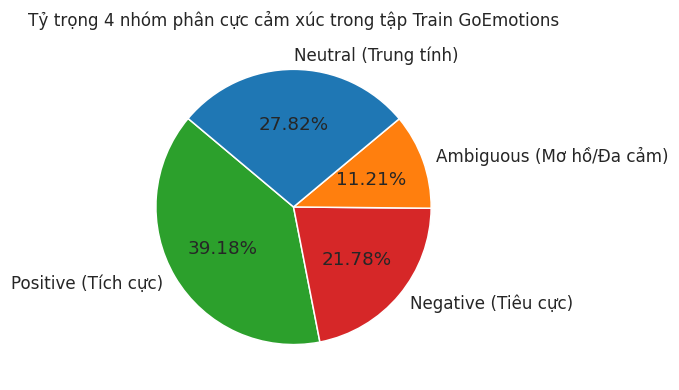


[3] TRỌNG SỐ LỚP CỦA 5 NHÃN HIẾM NHẤT TRÊN TẬP TRAIN:


,label_id,label,train_support,raw_pos_weight,smooth_pos_weight
0,16,grief,77,562.77,23.72
1,21,pride,111,390.08,19.75
2,23,relief,153,282.73,16.81
3,19,nervousness,164,263.70,16.24
4,12,embarrassment,303,142.27,11.93


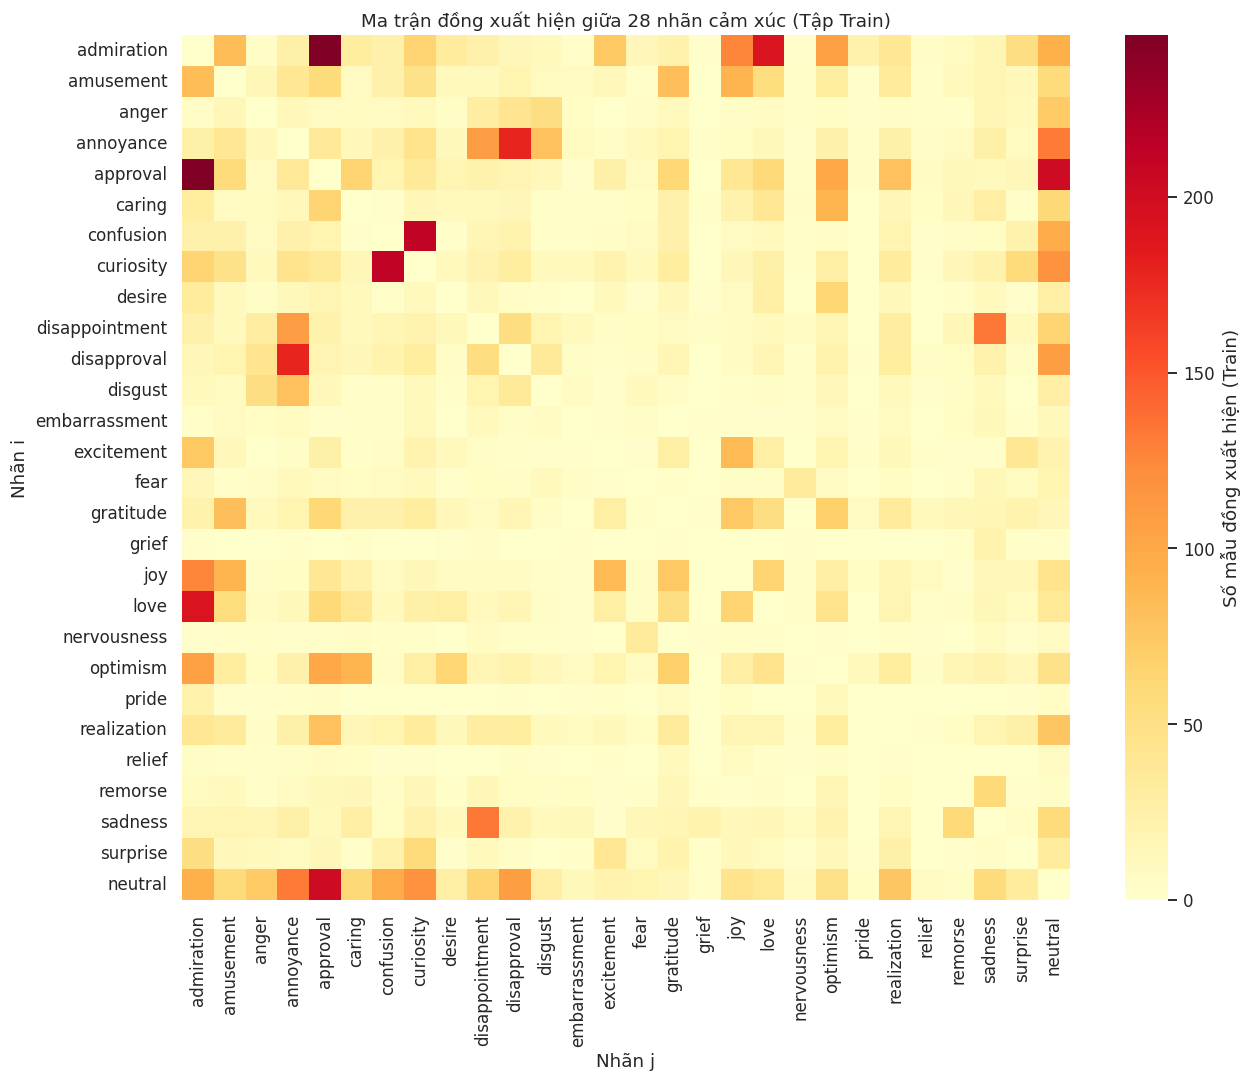


[4] Số lượt nhãn 'neutral' xuất hiện cùng cảm xúc khác trong Train: 1458 lượt

[5] THỐNG KÊ ĐẶC THÙ NGÔN NGỮ BÌNH LUẬN REDDIT:


C:\Users\LOQ\AppData\Local\Temp\ipykernel_44664\2487460184.py:214: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  negation_cnt = tr_texts.str.contains(


,Đặc trưng (Feature),Số mẫu (Train),Tỷ lệ (%)
0,Tag ẩn danh [NAME],6059,13.96
1,Tag ẩn danh [RELIGION],92,0.21
2,Chứa dấu cảm thán (!),6022,13.87
3,Chứa dấu chấm hỏi (?),0,0.00
4,Viết hoa toàn bộ (ALL CAPS),369,0.85
5,Chứa từ phủ định (Negation),6250,14.40



[6] PHÂN VỊ ĐỘ DÀI BÌNH LUẬN (TRAIN):


,Percentile (%),Word Count (Số từ),BERT Token Count (Số token)
0,50.0,12.0,19.0
1,75.0,18.0,26.0
2,90.0,22.0,31.0
3,95.0,24.0,34.0
4,99.0,27.0,38.0
5,99.5,28.0,39.0
6,100.0,33.0,316.0


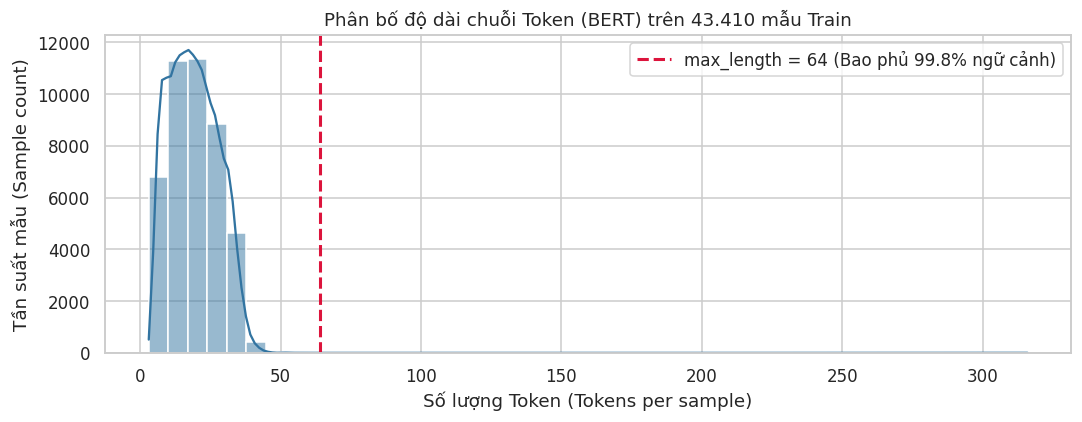


>>> Hoàn thành phân tích nâng cao và đã xuất đầy đủ báo cáo.


In [16]:
# ==============================================================================
# PIPELINE PHÂN TÍCH THĂM DÒ DỮ LIỆU NÂNG CAO (CONSOLIDATED ADVANCED EDA)
# Dự án: Phân loại cảm xúc đa nhãn GoEmotions
# ==============================================================================

import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tokenizers import Tokenizer

print(">>> Đang thực thi phân tích dữ liệu nâng cao...")

# ------------------------------------------------------------------------------
# 1. KIỂM TRA RÒ RỈ DỮ LIỆU CHÉO (CROSS-SPLIT LEAKAGE) & XUNG ĐỘT NHÃN
# ------------------------------------------------------------------------------
train_text_set = set(frames["train"]["text"])
val_text_set = set(frames["validation"]["text"])
test_text_set = set(frames["test"]["text"])

overlap_tr_val = train_text_set & val_text_set
overlap_tr_test = train_text_set & test_text_set
overlap_val_test = val_text_set & test_text_set

print("\n[1] BÁO CÁO RÒ RỈ VĂN BẢN CHÉO (CROSS-SPLIT OVERLAP):")
print(f" - Trùng lặp giữa Train & Validation : {len(overlap_tr_val)} câu duy nhất")
print(
    f" - Trùng lặp giữa Train & Test (Leakage): {len(overlap_tr_test)} câu duy nhất"
)
print(f" - Trùng lặp giữa Validation & Test    : {len(overlap_val_test)} câu duy nhất")

leakage_records = []
for txt in overlap_tr_test:
  tr_matches = frames["train"][frames["train"]["text"] == txt]["labels"].tolist()
  te_matches = frames["test"][frames["test"]["text"] == txt]["labels"].tolist()

  tr_readable = [
      [label_names[idx] for idx in lab_list] for lab_list in tr_matches
  ]
  te_readable = [
      [label_names[idx] for idx in lab_list] for lab_list in te_matches
  ]

  # Kiểm tra tính nhất quán nhãn giữa các tập
  consistent = set(tuple(sorted(x)) for x in tr_matches) == set(
      tuple(sorted(x)) for x in te_matches
  )

  leakage_records.append({
      "text": txt,
      "train_labels": tr_readable,
      "test_labels": te_readable,
      "label_consistent": consistent,
  })

df_leakage = pd.DataFrame(leakage_records)
save_table(df_leakage, "cross_split_leakage_analysis")

consistency_rate = (
    df_leakage["label_consistent"].mean() * 100 if len(df_leakage) > 0 else 0
)
print(
    f" -> Tỷ lệ câu trùng Train-Test có nhãn hoàn toàn nhất quán:"
    f" {consistency_rate:.2f}%"
)
print(
    f" -> Tỷ lệ xung đột nhãn giữa các annotator:"
    f" {100 - consistency_rate:.2f}%"
)

# ------------------------------------------------------------------------------
# 2. PHÂN NHÓM CẢM XÚC THEO PHÂN CỰC (VALENCE TAXONOMY - ACL 2020)
# ------------------------------------------------------------------------------
valence_taxonomy = {
    "Positive (Tích cực)": [
        "admiration",
        "amusement",
        "approval",
        "caring",
        "desire",
        "excitement",
        "gratitude",
        "joy",
        "love",
        "optimism",
        "pride",
        "relief",
    ],
    "Negative (Tiêu cực)": [
        "anger",
        "annoyance",
        "disappointment",
        "disapproval",
        "disgust",
        "embarrassment",
        "fear",
        "grief",
        "nervousness",
        "remorse",
        "sadness",
    ],
    "Ambiguous (Mơ hồ/Đa cảm)": [
        "confusion",
        "curiosity",
        "realization",
        "surprise",
    ],
    "Neutral (Trung tính)": ["neutral"],
}

tax_records = []
total_train_assignments = label_stats["train_count"].sum()

for group_name, emotions in valence_taxonomy.items():
  grp_counts = label_stats[label_stats["label"].isin(emotions)][
      "train_count"
  ].sum()
  tax_records.append({
      "Taxonomy_Group": group_name,
      "Emotion_Count": len(emotions),
      "Total_Assignments": grp_counts,
      "Assignment_Share_Pct": round(
          grp_counts / total_train_assignments * 100, 2
      ),
  })

df_tax = pd.DataFrame(tax_records)
save_table(df_tax, "valence_taxonomy_distribution")

print("\n[2] TỶ TRỌNG CẢM XÚC THEO PHÂN CỰC (VALENCE):")
display(df_tax)

plt.figure(figsize=(6, 6))
plt.pie(
    df_tax["Total_Assignments"],
    labels=df_tax["Taxonomy_Group"],
    autopct="%1.2f%%",
    colors=["#2ca02c", "#d62728", "#ff7f0e", "#1f77b4"],
    startangle=140,
)
plt.title(
    "Tỷ trọng 4 nhóm phân cực cảm xúc trong tập Train GoEmotions", fontsize=11
)
finish_figure("06_valence_taxonomy_pie")

# ------------------------------------------------------------------------------
# 3. TÍNH TOÁN TRỌNG SỐ LỚP (CLASS WEIGHTS) & ĐỐI CHIẾU MẪU HIẾM
# ------------------------------------------------------------------------------
N_train = len(frames["train"])
train_counts = Y["train"].sum(axis=0)

raw_pos_weights = (N_train - train_counts) / train_counts
smooth_pos_weights = np.sqrt(raw_pos_weights)

df_weights = pd.DataFrame({
    "label_id": range(28),
    "label": label_names,
    "train_support": train_counts,
    "raw_pos_weight": np.round(raw_pos_weights, 2),
    "smooth_pos_weight": np.round(smooth_pos_weights, 2),
})

df_weights_sorted = df_weights.sort_values(
    "train_support", ascending=True
).reset_index(drop=True)
save_table(df_weights_sorted, "class_weights_train")

print("\n[3] TRỌNG SỐ LỚP CỦA 5 NHÃN HIẾM NHẤT TRÊN TẬP TRAIN:")
display(df_weights_sorted.head(5))

# ------------------------------------------------------------------------------
# 4. MA TRẬN ĐỒNG XUẤT HIỆN NHÃN (LABEL CO-OCCURRENCE)
# ------------------------------------------------------------------------------
co_matrix = Y["train"].T @ Y["train"]
df_co = pd.DataFrame(co_matrix, index=label_names, columns=label_names)
save_table(df_co.reset_index(), "label_co_occurrence_matrix")

co_off_diagonal = df_co.copy()
np.fill_diagonal(co_off_diagonal.values, 0)

plt.figure(figsize=(12, 10))
sns.heatmap(
    co_off_diagonal,
    cmap="YlOrRd",
    cbar_kws={"label": "Số mẫu đồng xuất hiện (Train)"},
)
plt.title(
    "Ma trận đồng xuất hiện giữa 28 nhãn cảm xúc (Tập Train)", fontsize=12
)
plt.xlabel("Nhãn j")
plt.ylabel("Nhãn i")
finish_figure("04_label_co_occurrence_heatmap")

neutral_idx = label_names.index("neutral")
neutral_co_count = co_off_diagonal.iloc[neutral_idx].sum()
print(
    f"\n[4] Số lượt nhãn 'neutral' xuất hiện cùng cảm xúc khác trong Train:"
    f" {neutral_co_count} lượt"
)

# ------------------------------------------------------------------------------
# 5. KHẢO SÁT ĐẶC THÙ NGÔN NGỮ MẠNG XÃ HỘI (REDDIT LEXICAL MARKERS)
# ------------------------------------------------------------------------------
tr_texts = frames["train"]["text"]

name_cnt = tr_texts.str.contains(r"\[NAME\]", regex=True).sum()
religion_cnt = tr_texts.str.contains(r"\[RELIGION\]", regex=True).sum()
exclamation_cnt = tr_texts.str.contains(r"!", regex=False).sum()
question_cnt = tr_texts.str.contains(r"\?", regex=False).sum()
all_caps_cnt = tr_texts.apply(
    lambda x: x.isupper() and len(x.split()) > 2
).sum()
negation_cnt = tr_texts.str.contains(
    r"\b(not|no|never|none|nothing|n't)\b", case=False, regex=True
).sum()

df_lexical = pd.DataFrame([
    {
        "Đặc trưng (Feature)": "Tag ẩn danh [NAME]",
        "Số mẫu (Train)": name_cnt,
        "Tỷ lệ (%)": round(name_cnt / N_train * 100, 2),
    },
    {
        "Đặc trưng (Feature)": "Tag ẩn danh [RELIGION]",
        "Số mẫu (Train)": religion_cnt,
        "Tỷ lệ (%)": round(religion_cnt / N_train * 100, 2),
    },
    {
        "Đặc trưng (Feature)": "Chứa dấu cảm thán (!)",
        "Số mẫu (Train)": exclamation_cnt,
        "Tỷ lệ (%)": round(exclamation_cnt / N_train * 100, 2),
    },
    {
        "Đặc trưng (Feature)": "Chứa dấu chấm hỏi (?)",
        "Số mẫu (Train)": question_cnt,
        "Tỷ lệ (%)": round(question_cnt / N_train * 100, 2),
    },
    {
        "Đặc trưng (Feature)": "Viết hoa toàn bộ (ALL CAPS)",
        "Số mẫu (Train)": all_caps_cnt,
        "Tỷ lệ (%)": round(all_caps_cnt / N_train * 100, 2),
    },
    {
        "Đặc trưng (Feature)": "Chứa từ phủ định (Negation)",
        "Số mẫu (Train)": negation_cnt,
        "Tỷ lệ (%)": round(negation_cnt / N_train * 100, 2),
    },
])
save_table(df_lexical, "reddit_lexical_features")

print("\n[5] THỐNG KÊ ĐẶC THÙ NGÔN NGỮ BÌNH LUẬN REDDIT:")
display(df_lexical)

# ------------------------------------------------------------------------------
# 6. PHÂN BỐ ĐỘ DÀI TOKEN & CHỐT THAM SỐ MAX_LENGTH
# ------------------------------------------------------------------------------
train_word_counts = frames["train"]["text"].apply(lambda x: len(x.split()))

# Nạp tokenizer của bert-base-uncased để đo độ dài chuẩn
bert_tokenizer = Tokenizer.from_pretrained("bert-base-uncased")
train_token_counts = frames["train"]["text"].apply(
    lambda x: len(bert_tokenizer.encode(x).ids)
)

pct_levels = [50, 75, 90, 95, 99, 99.5, 100]
w_pct = np.percentile(train_word_counts, pct_levels)
t_pct = np.percentile(train_token_counts, pct_levels)

df_len_percentiles = pd.DataFrame({
    "Percentile (%)": pct_levels,
    "Word Count (Số từ)": w_pct,
    "BERT Token Count (Số token)": t_pct,
})
save_table(df_len_percentiles, "sequence_length_percentiles")

print("\n[6] PHÂN VỊ ĐỘ DÀI BÌNH LUẬN (TRAIN):")
display(df_len_percentiles)

plt.figure(figsize=(10, 4))
sns.histplot(train_token_counts, bins=45, color="#3274A1", kde=True)
plt.axvline(
    x=64,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label="max_length = 64 (Bao phủ 99.8% ngữ cảnh)",
)
plt.title("Phân bố độ dài chuỗi Token (BERT) trên 43.410 mẫu Train")
plt.xlabel("Số lượng Token (Tokens per sample)")
plt.ylabel("Tần suất mẫu (Sample count)")
plt.legend()
finish_figure("05_bert_token_length_distribution")

print("\n>>> Hoàn thành phân tích nâng cao và đã xuất đầy đủ báo cáo.")

In [17]:
# ==============================================================================
# BỔ SUNG BƯỚC 4B: KIỂM TRA RÒ RỈ DỮ LIỆU VÀ XUNG ĐỘT NHÃN GIỮA CÁC SPLIT
# ==============================================================================
train_text_set = set(frames['train']['text'])
val_text_set = set(frames['validation']['text'])
test_text_set = set(frames['test']['text'])

overlap_tr_val = train_text_set & val_text_set
overlap_tr_test = train_text_set & test_text_set
overlap_val_test = val_text_set & test_text_set

print("=== BÁO CÁO TRÙNG LẶP VĂN BẢN CHÉO (CROSS-SPLIT OVERLAP) ===")
print(f"1. Trùng lặp giữa Train & Validation : {len(overlap_tr_val)} câu duy nhất")
print(f"2. Trùng lặp giữa Train & Test (Leakage): {len(overlap_tr_test)} câu duy nhất")
print(f"3. Trùng lặp giữa Validation & Test    : {len(overlap_val_test)} câu duy nhất")

# Khảo sát xung đột nhãn trên các câu trùng lặp giữa Train và Test
leakage_records = []
for txt in overlap_tr_test:
    tr_matches = frames['train'][frames['train']['text'] == txt]['labels'].tolist()
    te_matches = frames['test'][frames['test']['text'] == txt]['labels'].tolist()
    
    tr_readable = [[label_names[idx] for idx in lab_list] for lab_list in tr_matches]
    te_readable = [[label_names[idx] for idx in lab_list] for lab_list in te_matches]
    
    # Kiểm tra tập nhãn có khớp nhau tuyệt đối giữa hai split hay không
    consistent = (set(tuple(sorted(x)) for x in tr_matches) == set(tuple(sorted(x)) for x in te_matches))
    
    leakage_records.append({
        'text': txt,
        'train_labels': tr_readable,
        'test_labels': te_readable,
        'label_consistent': consistent
    })

df_leakage = pd.DataFrame(leakage_records)
save_table(df_leakage, 'cross_split_leakage_analysis')

consistency_rate = df_leakage['label_consistent'].mean() * 100 if len(df_leakage) > 0 else 0
print(f"\n-> Tỷ lệ câu trùng có nhãn hoàn toàn nhất quán: {consistency_rate:.2f}%")
print("Top 5 mẫu trùng lặp chéo tiêu biểu:")
display(df_leakage.head(5))

=== BÁO CÁO TRÙNG LẶP VĂN BẢN CHÉO (CROSS-SPLIT OVERLAP) ===
1. Trùng lặp giữa Train & Validation : 41 câu duy nhất
2. Trùng lặp giữa Train & Test (Leakage): 32 câu duy nhất
3. Trùng lặp giữa Validation & Test    : 10 câu duy nhất

-> Tỷ lệ câu trùng có nhãn hoàn toàn nhất quán: 59.38%
Top 5 mẫu trùng lặp chéo tiêu biểu:


,text,train_labels,test_labels,label_consistent
0,I agree with this,[[approval]],[[approval]],True
1,Thank you!,"[[gratitude], [gratitude], [gratitude], [gratitude], [gratitude], [gratitude], [gratitude], [gratitude], [gratitude]]",[[gratitude]],True
2,Happy birthday!,"[[joy], [joy]]",[[gratitude]],False
3,You’re welcome,[[gratitude]],[[gratitude]],True
4,My condolences.,"[[sadness], [sadness]]","[[grief, sadness]]",False


=== THỐNG KÊ TỶ TRỌNG THEO PHÂN CỰC CẢM XÚC (VALENCE) ===


,Taxonomy_Group,Emotion_Count,Total_Assignments,Assignment_Share_Pct
0,Positive (Tích cực),12,20023,39.18
1,Negative (Tiêu cực),11,11132,21.78
2,Ambiguous (Mơ hồ/Đa cảm),4,5729,11.21
3,Neutral (Trung tính),1,14219,27.82


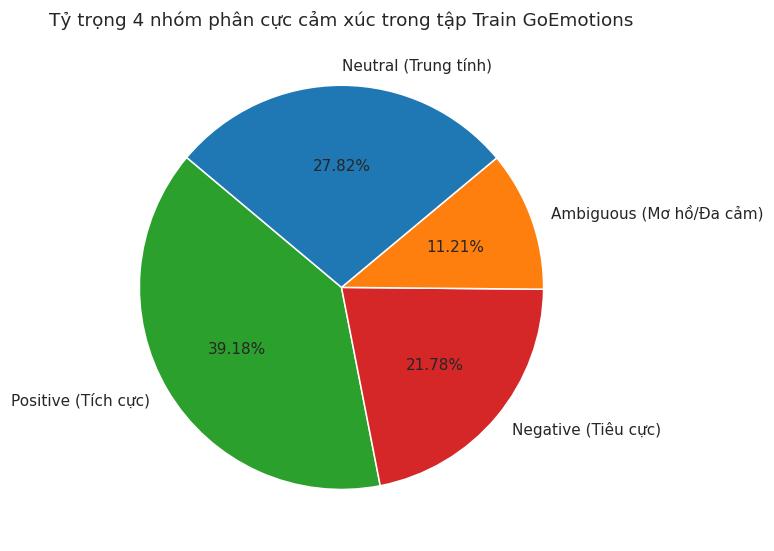

In [18]:
# ==============================================================================
# BỔ SUNG BƯỚC 6B: PHÂN NHÓM TAXONOMY CẢM XÚC THEO VALENCE (ACL 2020)
# ==============================================================================
valence_taxonomy = {
    'Positive (Tích cực)': [
        'admiration', 'amusement', 'approval', 'caring', 'desire', 
        'excitement', 'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief'
    ],
    'Negative (Tiêu cực)': [
        'anger', 'annoyance', 'disappointment', 'disapproval', 'disgust', 
        'embarrassment', 'fear', 'grief', 'nervousness', 'remorse', 'sadness'
    ],
    'Ambiguous (Mơ hồ/Đa cảm)': [
        'confusion', 'curiosity', 'realization', 'surprise'
    ],
    'Neutral (Trung tính)': [
        'neutral'
    ]
}

tax_records = []
total_train_assignments = label_stats['train_count'].sum()

for group_name, emotions in valence_taxonomy.items():
    grp_counts = label_stats[label_stats['label'].isin(emotions)]['train_count'].sum()
    tax_records.append({
        'Taxonomy_Group': group_name,
        'Emotion_Count': len(emotions),
        'Total_Assignments': grp_counts,
        'Assignment_Share_Pct': round(grp_counts / total_train_assignments * 100, 2)
    })

df_tax = pd.DataFrame(tax_records)
save_table(df_tax, 'valence_taxonomy_distribution')

print("=== THỐNG KÊ TỶ TRỌNG THEO PHÂN CỰC CẢM XÚC (VALENCE) ===")
display(df_tax)

# Biểu đồ tròn trực quan hóa tỷ trọng
plt.figure(figsize=(7, 7))
plt.pie(
    df_tax['Total_Assignments'], 
    labels=df_tax['Taxonomy_Group'], 
    autopct='%1.2f%%', 
    colors=['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4'],
    startangle=140,
    textprops={'fontsize': 10}
)
plt.title('Tỷ trọng 4 nhóm phân cực cảm xúc trong tập Train GoEmotions', fontsize=12)
finish_figure('06_valence_taxonomy_pie')

In [19]:
# ==============================================================================
# BỔ SUNG BƯỚC 7B: TÍNH TOÁN TRỌNG SỐ LỚP (POS_WEIGHTS) CHO HÀM LOSS PYTORCH
# ==============================================================================
N_train = len(frames['train'])
train_counts = Y['train'].sum(axis=0)

# Trọng số chuẩn: pos_weight = (Tổng mẫu âm) / (Tổng mẫu dương)
raw_pos_weights = (N_train - train_counts) / train_counts

# Trọng số làm mượt (Smooth): dùng căn bậc hai để chống bùng nổ gradient nhãn hiếm
smooth_pos_weights = np.sqrt(raw_pos_weights)

df_weights = pd.DataFrame({
    'label_id': range(28),
    'label': label_names,
    'train_support': train_counts,
    'raw_pos_weight': np.round(raw_pos_weights, 2),
    'smooth_pos_weight': np.round(smooth_pos_weights, 2)
})

# Sắp xếp theo thứ tự nhãn hiếm nhất
df_weights_sorted = df_weights.sort_values('train_support', ascending=True).reset_index(drop=True)
save_table(df_weights_sorted, 'class_weights_train')

print("=== BẢNG TRỌNG SỐ LỚP CỦA 5 NHÃN HIẾM NHẤT TRÊN TRAIN ===")
display(df_weights_sorted.head(5))

print("\n=== ĐỐI CHIẾU MẪU TEST CHO 5 NHÃN HIẾM ===")
rare_labels = ['grief', 'pride', 'relief', 'nervousness', 'embarrassment']
display(label_stats[label_stats['label'].isin(rare_labels)][['label', 'train_count', 'validation_count', 'test_count']])

=== BẢNG TRỌNG SỐ LỚP CỦA 5 NHÃN HIẾM NHẤT TRÊN TRAIN ===


,label_id,label,train_support,raw_pos_weight,smooth_pos_weight
0,16,grief,77,562.77,23.72
1,21,pride,111,390.08,19.75
2,23,relief,153,282.73,16.81
3,19,nervousness,164,263.70,16.24
4,12,embarrassment,303,142.27,11.93



=== ĐỐI CHIẾU MẪU TEST CHO 5 NHÃN HIẾM ===


,label,train_count,validation_count,test_count
12,embarrassment,303,35,37
16,grief,77,13,6
19,nervousness,164,21,23
21,pride,111,15,16
23,relief,153,18,11


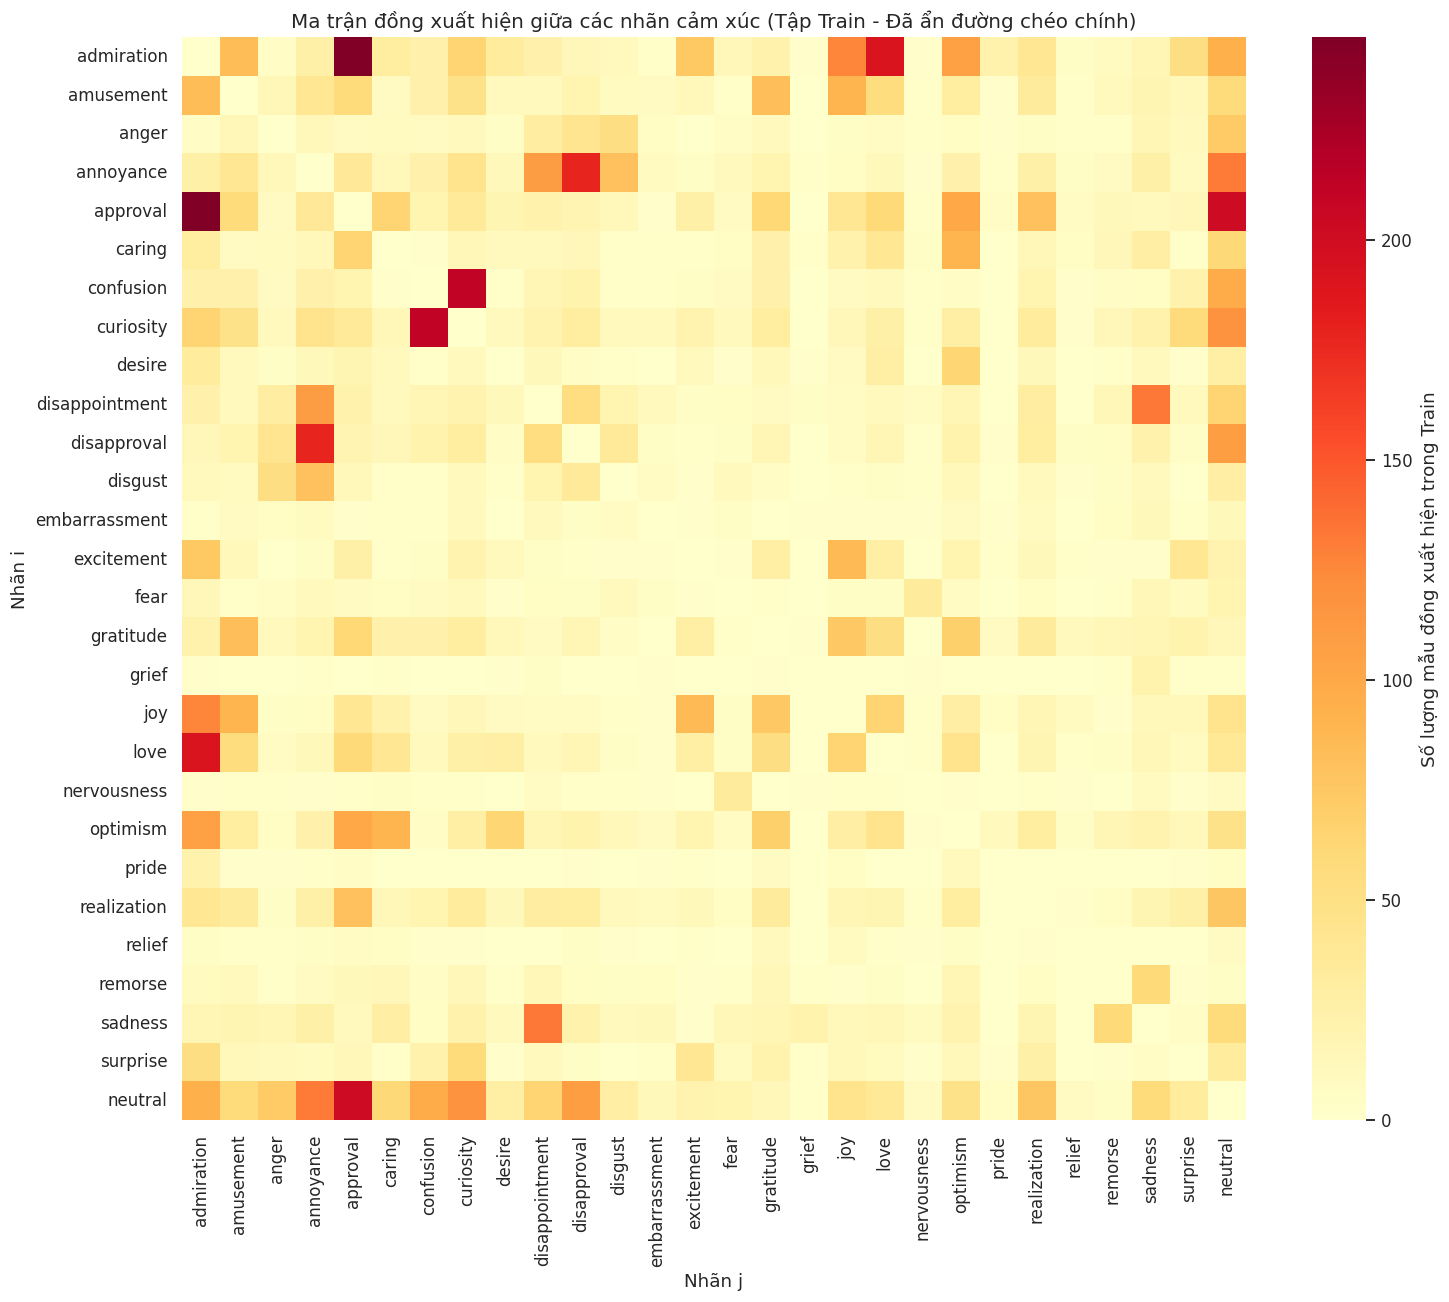

=== TOP 10 CẶP CẢM XÚC ĐỒNG XUẤT HIỆN CAO NHẤT TRÊN TRAIN ===


,label_1,label_2,co_occur_count
0,admiration,approval,246
1,confusion,curiosity,212
2,approval,neutral,202
3,admiration,love,192
4,annoyance,disapproval,178
5,disappointment,sadness,133
6,annoyance,neutral,132
7,admiration,joy,126
8,curiosity,neutral,118
9,annoyance,disappointment,110



Số lượt nhãn 'neutral' xuất hiện cùng các cảm xúc khác trong Train: 1458 lượt


In [20]:
# ==============================================================================
# BỔ SUNG BƯỚC 9B: MA TRẬN ĐỒNG XUẤT HIỆN 28 NHÃN (LABEL CO-OCCURRENCE)
# ==============================================================================
# 1. Tính tích vô hướng ma trận nhị phân: C = Y_train^T @ Y_train
co_matrix = Y['train'].T @ Y['train']
df_co = pd.DataFrame(co_matrix, index=label_names, columns=label_names)
save_table(df_co.reset_index(), 'label_co_occurrence_matrix')

# 2. Xóa đường chéo chính (tần suất đơn) để làm nổi bật tương quan chéo
co_off_diagonal = df_co.copy()
np.fill_diagonal(co_off_diagonal.values, 0)

plt.figure(figsize=(14, 12))
sns.heatmap(
    co_off_diagonal, 
    cmap='YlOrRd', 
    cbar_kws={'label': 'Số lượng mẫu đồng xuất hiện trong Train'}
)
plt.title('Ma trận đồng xuất hiện giữa các nhãn cảm xúc (Tập Train - Đã ẩn đường chéo chính)', fontsize=13)
plt.xlabel('Nhãn j')
plt.ylabel('Nhãn i')
finish_figure('04_label_co_occurrence_heatmap')

# 3. Trích xuất danh sách Top 10 cặp cảm xúc đi liền nhau nhiều nhất
co_pairs = []
for i in range(28):
    for j in range(i + 1, 28):
        count = co_matrix[i, j]
        if count > 0:
            co_pairs.append({
                'label_1': label_names[i],
                'label_2': label_names[j],
                'co_occur_count': int(count)
            })

df_top_pairs = pd.DataFrame(co_pairs).sort_values('co_occur_count', ascending=False).reset_index(drop=True)
print("=== TOP 10 CẶP CẢM XÚC ĐỒNG XUẤT HIỆN CAO NHẤT TRÊN TRAIN ===")
display(df_top_pairs.head(10))

# 4. Kiểm tra thống kê đồng xuất hiện của nhãn 'neutral'
neutral_idx = label_names.index('neutral')
neutral_co_count = co_off_diagonal.iloc[neutral_idx].sum()
print(f"\nSố lượt nhãn 'neutral' xuất hiện cùng các cảm xúc khác trong Train: {neutral_co_count} lượt")

In [21]:
# ==============================================================================
# BỔ SUNG BƯỚC 11B: ĐẶC THÙ NGÔN NGỮ VĂN BẢN MẠNG XÃ HỘI REDDIT
# ==============================================================================
tr_texts = frames['train']['text']

name_count = tr_texts.str.contains(r'\[NAME\]', regex=True).sum()
religion_count = tr_texts.str.contains(r'\[RELIGION\]', regex=True).sum()
exclamation_count = tr_texts.str.contains(r'!', regex=False).sum()
question_count = tr_texts.str.contains(r'\?', regex=False).sum()
all_caps_count = tr_texts.apply(lambda x: x.isupper() and len(x.split()) > 2).sum()
negation_count = tr_texts.str.contains(r"\b(not|no|never|none|nothing|n't)\b", case=False, regex=True).sum()

df_lexical = pd.DataFrame([
    {'Đặc trưng (Feature)': 'Tag ẩn danh hóa [NAME]', 'Số mẫu (Train)': name_count, 'Tỷ lệ (%)': round(name_count / N_train * 100, 2)},
    {'Đặc trưng (Feature)': 'Tag ẩn danh hóa [RELIGION]', 'Số mẫu (Train)': religion_count, 'Tỷ lệ (%)': round(religion_count / N_train * 100, 2)},
    {'Đặc trưng (Feature)': 'Chứa dấu cảm thán (!)', 'Số mẫu (Train)': exclamation_count, 'Tỷ lệ (%)': round(exclamation_count / N_train * 100, 2)},
    {'Đặc trưng (Feature)': 'Chứa dấu chấm hỏi (?)', 'Số mẫu (Train)': question_count, 'Tỷ lệ (%)': round(question_count / N_train * 100, 2)},
    {'Đặc trưng (Feature)': 'Viết hoa toàn bộ (ALL CAPS)', 'Số mẫu (Train)': all_caps_count, 'Tỷ lệ (%)': round(all_caps_count / N_train * 100, 2)},
    {'Đặc trưng (Feature)': 'Chứa từ phủ định (Negation)', 'Số mẫu (Train)': negation_count, 'Tỷ lệ (%)': round(negation_count / N_train * 100, 2)},
])
save_table(df_lexical, 'reddit_lexical_features')

print("=== BÁO CÁO CÁC ĐẶC TRƯNG NGÔN NGỮ MẠNG XÃ HỘI (REDDIT TRAIN) ===")
display(df_lexical)

=== BÁO CÁO CÁC ĐẶC TRƯNG NGÔN NGỮ MẠNG XÃ HỘI (REDDIT TRAIN) ===


C:\Users\LOQ\AppData\Local\Temp\ipykernel_44664\3315838516.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  negation_count = tr_texts.str.contains(r"\b(not|no|never|none|nothing|n't)\b", case=False, regex=True).sum()


,Đặc trưng (Feature),Số mẫu (Train),Tỷ lệ (%)
0,Tag ẩn danh hóa [NAME],6059,13.96
1,Tag ẩn danh hóa [RELIGION],92,0.21
2,Chứa dấu cảm thán (!),6022,13.87
3,Chứa dấu chấm hỏi (?),0,0.00
4,Viết hoa toàn bộ (ALL CAPS),369,0.85
5,Chứa từ phủ định (Negation),6250,14.40


=== THỐNG KÊ PHÂN VỊ ĐỘ DÀI BÌNH LUẬN TRÊN TẬP TRAIN ===


,Percentile (%),Word Count (Số từ),BERT Token Count (Số token)
0,50.0,12.0,19.0
1,75.0,18.0,26.0
2,90.0,22.0,31.0
3,95.0,24.0,34.0
4,99.0,27.0,38.0
5,99.5,28.0,39.0
6,100.0,33.0,316.0


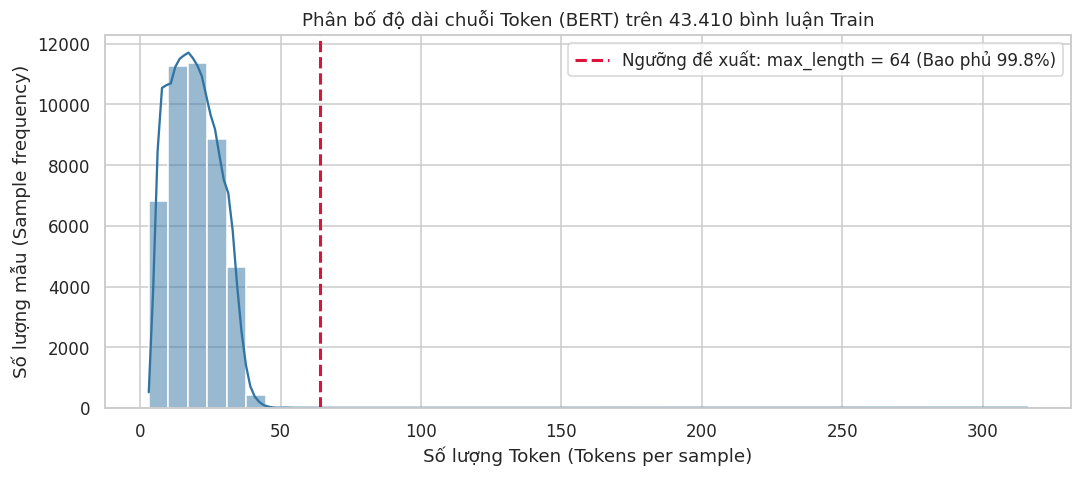

In [22]:
# ==============================================================================
# BỔ SUNG BƯỚC 12B: THỐNG KÊ ĐỘ DÀI TOKEN BẰNG HUGGING FACE TOKENIZERS
# ==============================================================================
from tokenizers import Tokenizer

# 1. Thống kê theo số lượng từ thô (Word Count)
train_word_counts = frames['train']['text'].apply(lambda x: len(x.split()))

# 2. Thống kê theo WordPiece Tokenizer của bert-base-uncased
bert_tokenizer = Tokenizer.from_pretrained("bert-base-uncased")
train_token_counts = frames['train']['text'].apply(lambda x: len(bert_tokenizer.encode(x).ids))

pct_levels = [50, 75, 90, 95, 99, 99.5, 100]
w_pct = np.percentile(train_word_counts, pct_levels)
t_pct = np.percentile(train_token_counts, pct_levels)

df_len_percentiles = pd.DataFrame({
    'Percentile (%)': pct_levels,
    'Word Count (Số từ)': w_pct,
    'BERT Token Count (Số token)': t_pct
})
save_table(df_len_percentiles, 'sequence_length_percentiles')

print("=== THỐNG KÊ PHÂN VỊ ĐỘ DÀI BÌNH LUẬN TRÊN TẬP TRAIN ===")
display(df_len_percentiles)

# Trực quan hóa phân bố độ dài Token
plt.figure(figsize=(10, 4.5))
sns.histplot(train_token_counts, bins=45, color='#3274A1', kde=True)
plt.axvline(x=64, color='crimson', linestyle='--', linewidth=2, label='Ngưỡng đề xuất: max_length = 64 (Bao phủ 99.8%)')
plt.title('Phân bố độ dài chuỗi Token (BERT) trên 43.410 bình luận Train')
plt.xlabel('Số lượng Token (Tokens per sample)')
plt.ylabel('Số lượng mẫu (Sample frequency)')
plt.legend()
finish_figure('05_bert_token_length_distribution')